# Import Ntuple

In [1]:
%load_ext autoreload
%autoreload 2

import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import sys
# sys.path.insert(0, "/home/belle/zhangboy/B2SW/2025_VirginiaTech/sysvar/src/")
sys.path.append('/home/belle/zhangboy/inclusive_R_D/')
import utilities as util

training_variables = util.training_variables
columns = util.all_relevant_variables
offline_cut = util.offline_cut
lgb_tight = util.lgb_tight
lgb_loose = util.lgb_loose
lgb_comb = util.lgb_comb

In [2]:
# 4S Data vs MC
# (DstVeto_massDiff_0<0.135 or 0.145<DstVeto_massDiff_0) and 1.855<D_M<1.885

# Load data files
MC_4S_loose = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/4S_run1_deimos_BDT_e_3.root:MC_e_loose'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

data_4S_loose = uproot.concatenate(['/home/belle/zhangboy/inclusive_R_D/Samples/4S_run1_deimos_BDT_e_3.root:Data_e_loose'],
                          library="pd",
                          cut = offline_cut,
                          filter_branch=lambda branch: branch.name in columns)

pi0_eff_table = '/home/belle/zhangboy/inclusive_R_D/MC16_sys_tables/pi0_eff50_corr.csv'
MC_4S_loose = util.apply_pi0_eff_correction(MC_4S_loose, pi0_eff_table)
MC_4S_loose = util.apply_pid_corrections(df=MC_4S_loose, run='run1', channel='e', corr_col_name='total_PIDweight')

# df_mc_4S_loose['ell_BFbrems_mcPDG'] = df_mc_4S_loose['ell_mcPDG']
samples=util.classify_mc_dict(MC_4S_loose, 'e', template=False)

mpl_mc=util.mpl(samples)
mpl=util.mpl(samples, data_4S_loose)

          pi0_p  pi0_cosTheta
count  490565.0      490565.0
mean       -1.0          -1.0
std         0.0           0.0
min        -1.0          -1.0
25%        -1.0          -1.0
50%        -1.0          -1.0
75%        -1.0          -1.0
max        -1.0          -1.0
Required variables: ['ell_BFbrems_p', 'ell_BFbrems_charge', 'ell_BFbrems_cosTheta', 'ell_BFbrems_PDG', 'ell_BFbrems_mcPDG']
Required variables: ['K_p', 'K_charge', 'K_cosTheta', 'K_PDG', 'K_mcPDG']
Required variables: ['pi1_p', 'pi1_charge', 'pi1_cosTheta', 'pi1_PDG', 'pi1_mcPDG']
Required variables: ['pi2_p', 'pi2_charge', 'pi2_cosTheta', 'pi2_PDG', 'pi2_mcPDG']


In [ ]:
# # Load the PID weights saved from systematic correction framework
# from sysvar import add_weights_to_dataframe

# add_weights_to_dataframe(
#     df = df_mc_4S_loose,
#     systematic= "eID_eff",
#     MC_production= "MC15rd",
#     prefix= "ell",
#     weightname ="eID_eff_weight",
#     #overwrite: False,
#     #Nvar: 0
# )

# add_weights_to_dataframe(
#     df = df_mc_4S_loose,
#     systematic= "eID_pi_fake",
#     MC_production= "MC15rd",
#     prefix= "ell",
#     weightname ="eID_pi_fake_weight",
#     #overwrite: False,
#     #Nvar: 0
# )

# add_weights_to_dataframe(
#     df = df_mc_4S_loose,
#     systematic= "eID_K_fake",
#     MC_production= "MC15rd",
#     prefix= "ell",
#     weightname ="eID_K_fake_weight",
#     #overwrite: False,
#     #Nvar: 0
# )

# # if multiple correction weights exist, combine them
# df_mc_4S_loose["total_PID_weight"] = df_mc_4S_loose[["ell_eID_eff_weight", "ell_eID_pi_fake_weight", "ell_eID_K_fake_weight",]].product(axis = 1)

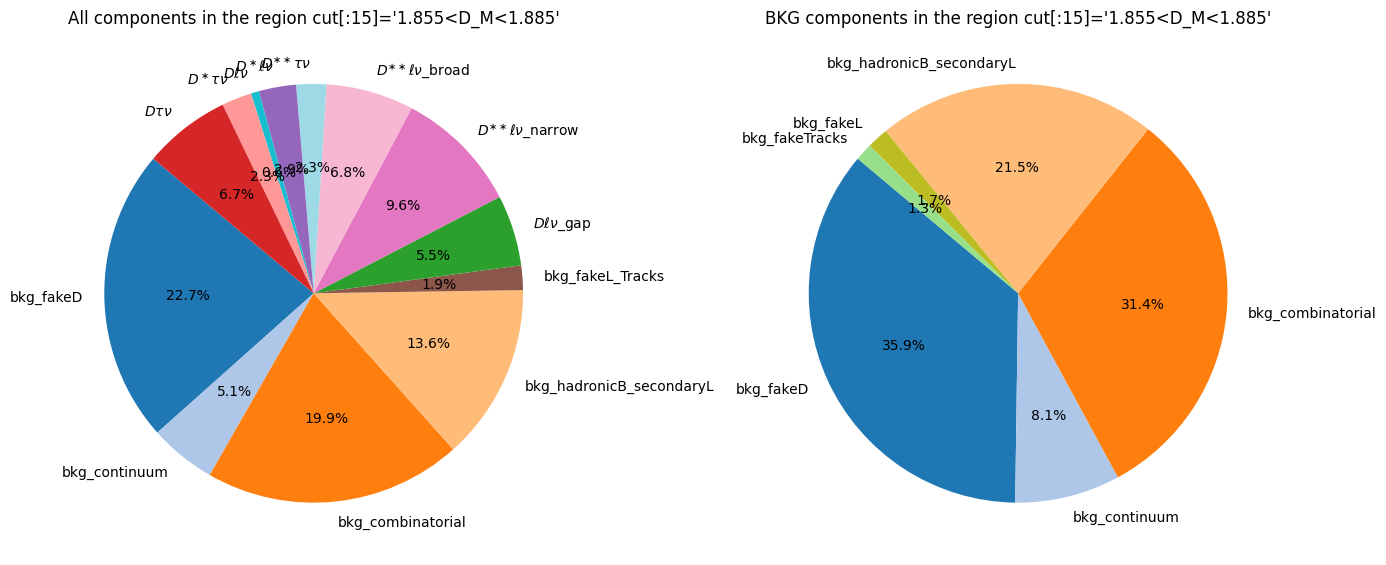

In [19]:
# new
cut_test = f'1.855<D_M<1.885 and {lgb_tight} and (DstVeto_massDiff_0<0.135 or 0.145<DstVeto_massDiff_0) and 7.5>B0_recMissM2>1.7 and p_D_l<2.7'
mpl_mc.plot_pie(cut=cut_test)


[bkg_combinatorial] N=116405  sum(BB_weight)=112808.836
D_category
BBbar_unmeasured:5+-body    29777.000000
BBbar_unmeasured:4-body     22604.000000
BBbar_measured_hadronic     22101.267896
BBbar_semileptonic          19993.000000
BBbar_unmeasured:3-body     17998.000000
BBbar_unmeasured:2-body      2105.000000
Name: D_side_weight, dtype: float64


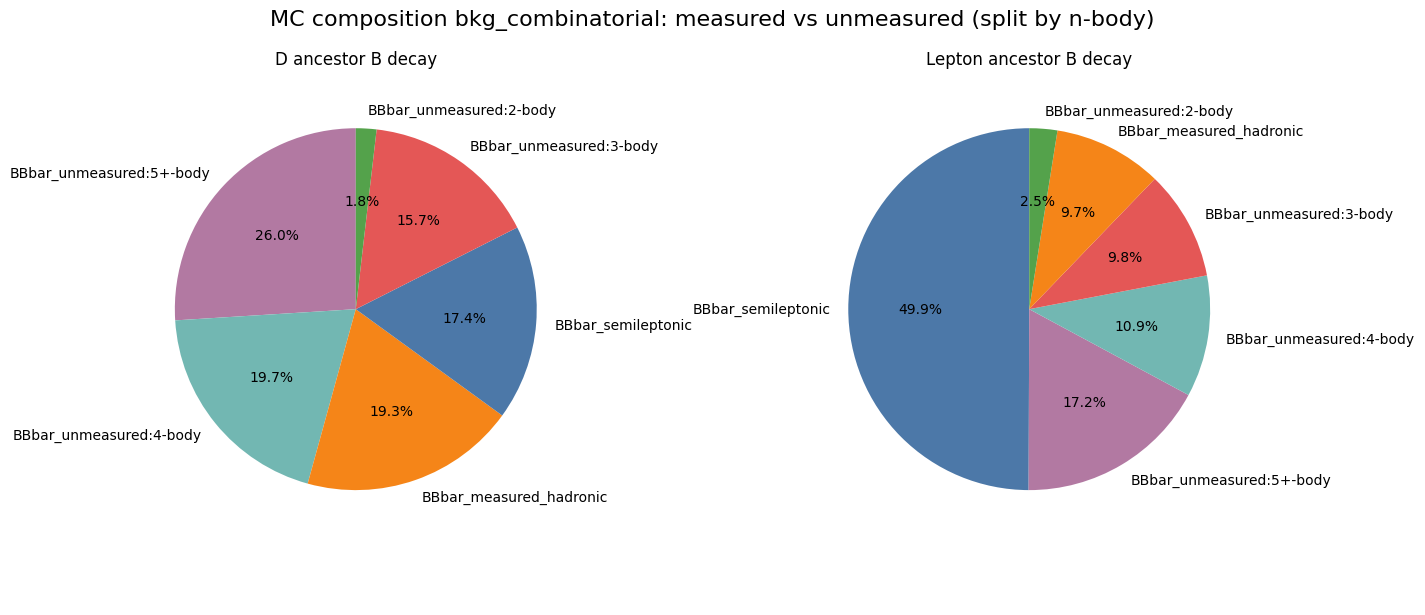


[bkg_hadronicB_secondaryL] N=51692  sum(BB_weight)=48136.701
D_category
BBbar_measured_hadronic     22656.700916
BBbar_unmeasured:3-body      9706.000000
BBbar_unmeasured:4-body      8956.000000
BBbar_unmeasured:5+-body     3504.000000
BBbar_unmeasured:2-body      2846.000000
BBbar_semileptonic            468.000000
Name: D_side_weight, dtype: float64


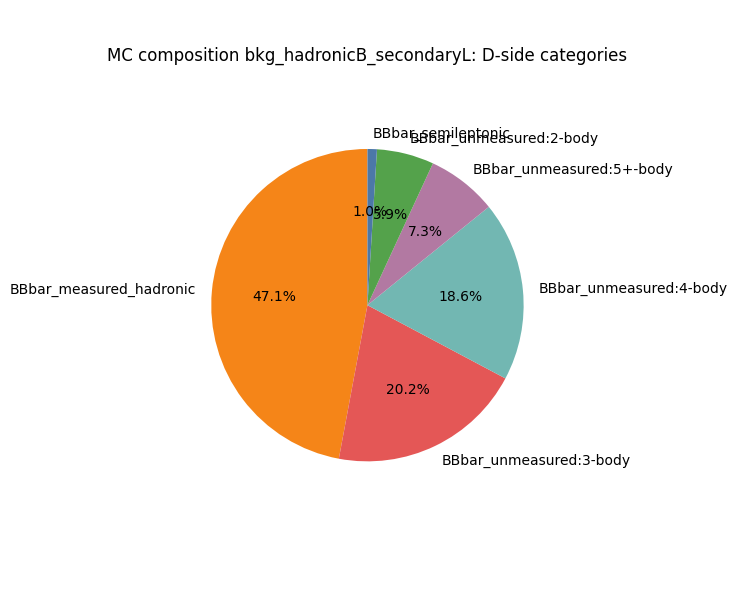

In [18]:
weights={'BBbar_measured_hadronic':1,
         'BBbar_semileptonic': 1,
         'BBbar_unmeasured:2-body':1,
         'BBbar_unmeasured:3-body':1,
         'BBbar_unmeasured:4-body':1,
         'BBbar_unmeasured:5+-body':1,}

samples_comb_sub = util.reweight_BBbar_background(samples, weight_map = weights, out_weight_col = "BB_weight",
                    weight_ell_side = True, verbose= True, cap_nbody = 5, warn_missing_weight_keys = True,
                    D_replacement_map = None, ell_replacement_map = None)
# for name, df in samples_comb_sub.items():
#     df['total_weight'] = df["total_PIDweight"] * df['BB_weight']
# mpl_comb_sub=util.mpl(samples_comb_sub,data_4S_loose)

In [20]:
# new
for name, df in samples.items():
    print(name, len(df.query(cut_test)))
print()
for name, df in samples.items():
    print(name, len(df.query(cut_test + ' and combinatorial_prob<0.3')))

bkg_fakeD 15873
bkg_fakeL 733
bkg_fakeTracks 592
bkg_continuum 3597
bkg_combinatorial 13903
bkg_hadronicB_secondaryL 9530
bkg_other_TDTl 0
$D\tau\nu$ 4707
$D^\ast\tau\nu$ 1621
$D\ell\nu$ 435
$D^\ast\ell\nu$ 2010
$D^{\ast\ast}\tau\nu$ 1622
$D^{\ast\ast}\ell\nu$_narrow 6744
$D^{\ast\ast}\ell\nu$_broad 4738
$D\ell\nu$_gap 3824
bkg_other_signal 0

bkg_fakeD 14232
bkg_fakeL 607
bkg_fakeTracks 525
bkg_continuum 3339
bkg_combinatorial 10988
bkg_hadronicB_secondaryL 8308
bkg_other_TDTl 0
$D\tau\nu$ 4439
$D^\ast\tau\nu$ 1486
$D\ell\nu$ 397
$D^\ast\ell\nu$ 1811
$D^{\ast\ast}\tau\nu$ 1457
$D^{\ast\ast}\ell\nu$_narrow 6209
$D^{\ast\ast}\ell\nu$_broad 4423
$D\ell\nu$_gap 3420
bkg_other_signal 0


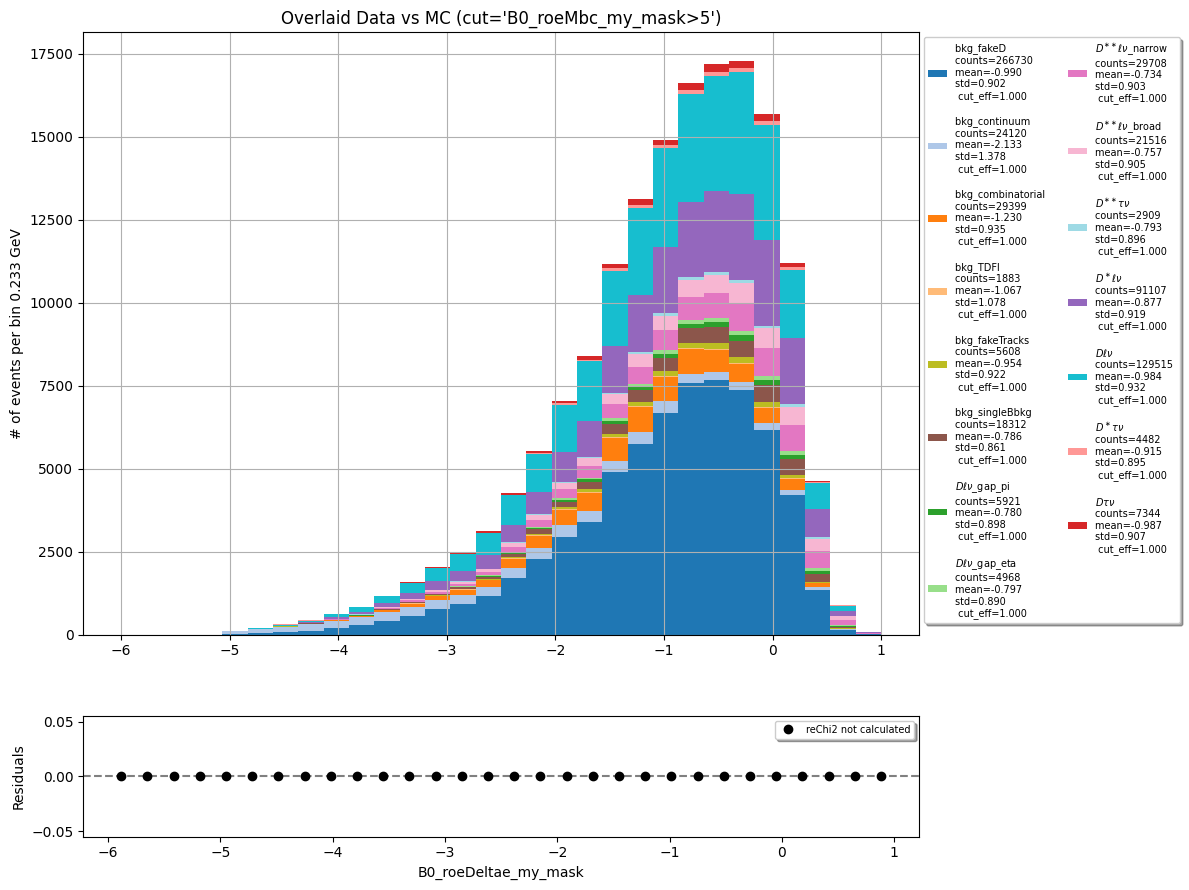

In [71]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(-6,1,31)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_mc.plot_data_mc_stacked(
    variable='B0_roeDeltae_my_mask',bins=b1,cut='B0_roeMbc_my_mask>5',correction=False,mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7, weights=weights)

cut= sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6


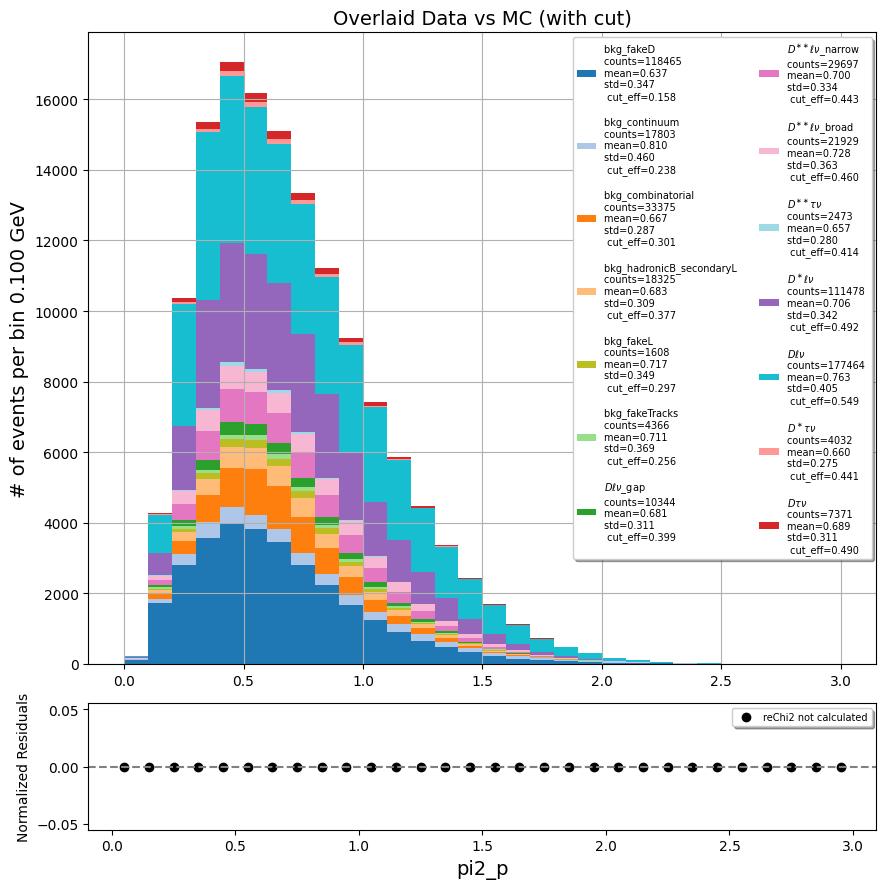

In [16]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(0,3,31)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_mc.plot_data_mc_stacked(
    variable='pi2_p',bins=b1,cut=f'{lgb_tight}',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= 1.855<D_M<1.885 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 2<p_D_l and B0_recQ2BhSimple<10 and (DstVeto_massDiff_0<0.135 or 0.145<DstVeto_massDiff_0)


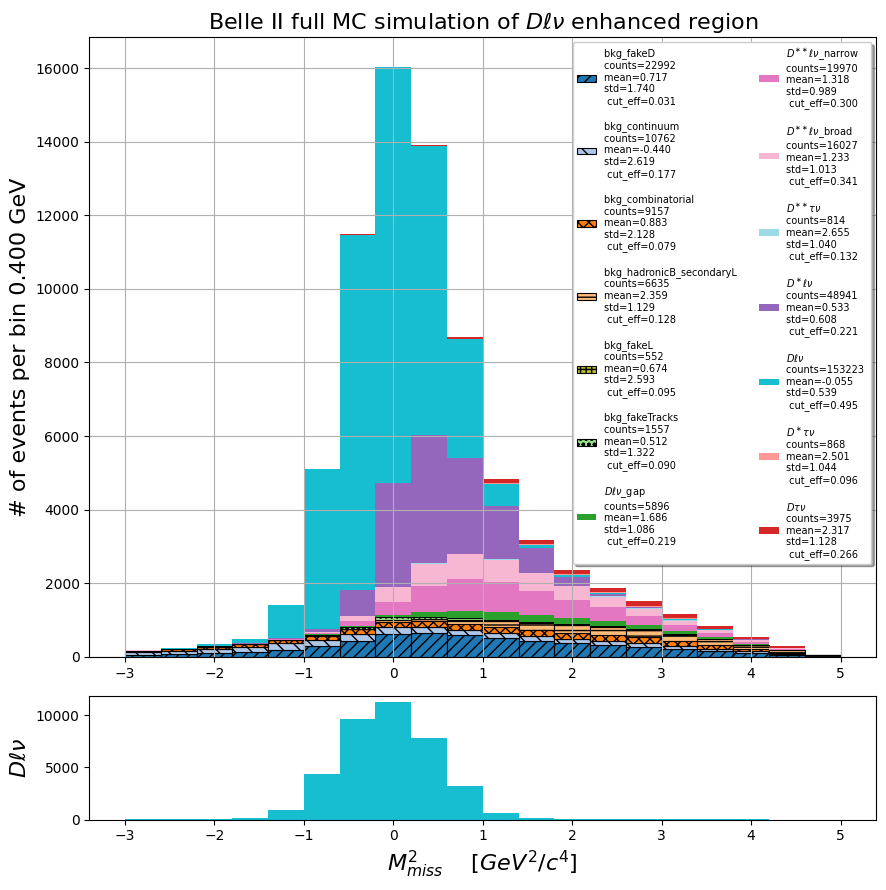

In [13]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(-3,5,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_mc.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut=f'1.855<D_M<1.885 and {lgb_tight} and 2<p_D_l and B0_recQ2BhSimple<10 and (DstVeto_massDiff_0<0.135 or 0.145<DstVeto_massDiff_0)',mask=[],
    figsize=(12,9),legend_nc=2,legend_fs=7,text_fs=16,bottom_plot=r'$D\ell\nu$',title=r'Belle II full MC simulation of $D\ell\nu$ enhanced region',
    weights=weights,apply_eventByEvent_correction=False, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= 1.855<D_M<1.885 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and B0_recMissM2<2.5 and B0_recQ2BhSimple<10 and (DstVeto_massDiff_0<0.135 or 0.145<DstVeto_massDiff_0)


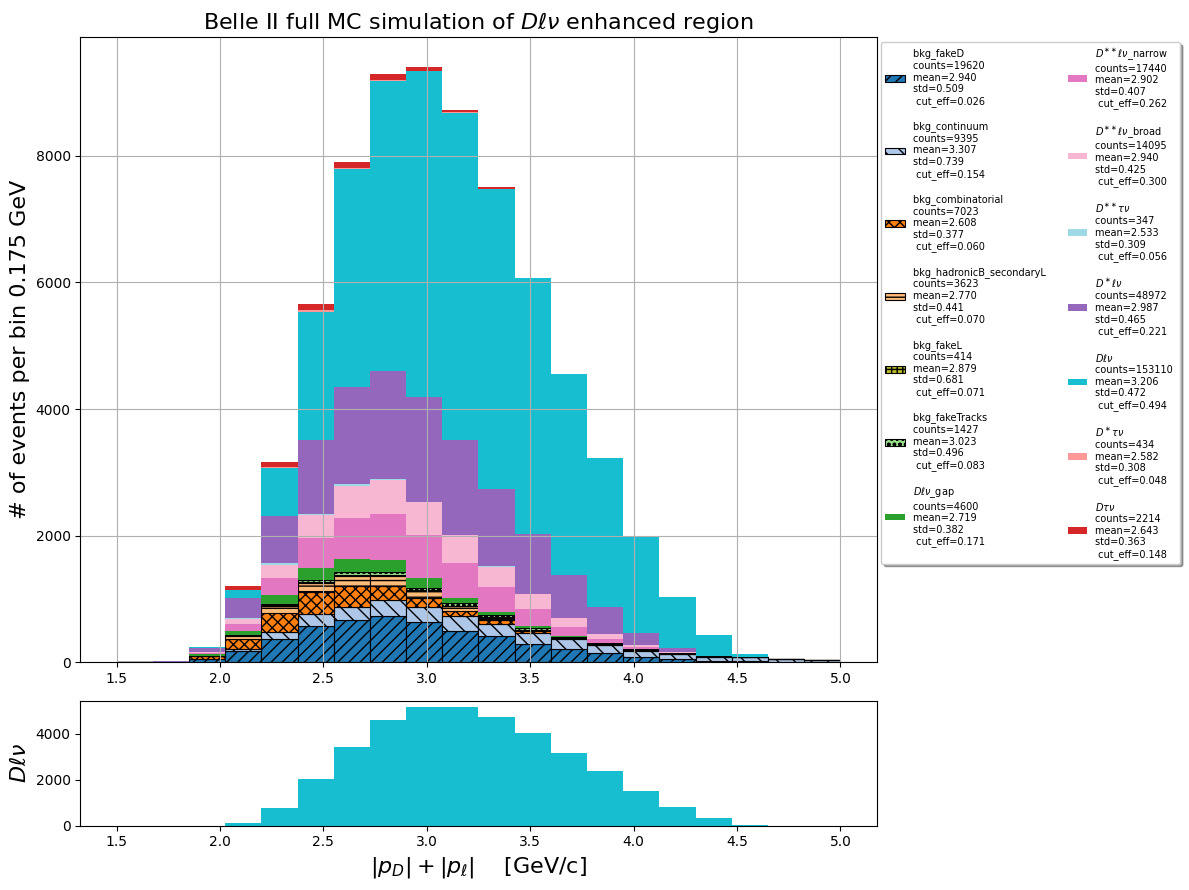

In [14]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(1.5,5,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_mc.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut=f'1.855<D_M<1.885 and {lgb_tight} and B0_recMissM2<2.5 and B0_recQ2BhSimple<10 and (DstVeto_massDiff_0<0.135 or 0.145<DstVeto_massDiff_0)',mask=[],
    figsize=(12,9),legend_nc=2,legend_fs=7,text_fs=16,bottom_plot=r'$D\ell\nu$',title=r'Belle II full MC simulation of $D\ell\nu$ enhanced region',
    weights=weights,apply_eventByEvent_correction=False, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= 1.855<D_M<1.885 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and p_D_l<2.7 and 3<B0_recQ2BhSimple and (DstVeto_massDiff_0<0.135 or 0.145<DstVeto_massDiff_0)


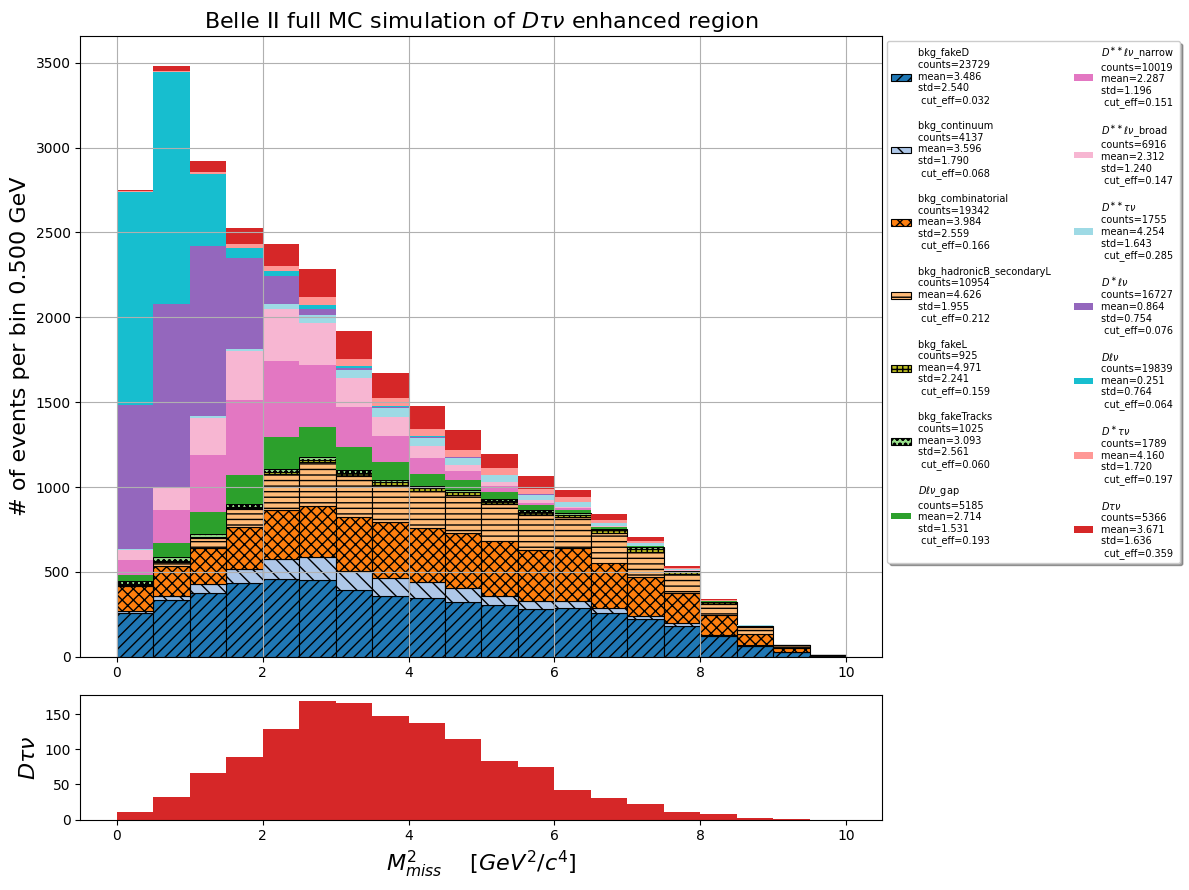

In [15]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(0,10,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_mc.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,mask=[],
    cut=f'1.855<D_M<1.885 and {lgb_tight} and p_D_l<2.7 and 3<B0_recQ2BhSimple and (DstVeto_massDiff_0<0.135 or 0.145<DstVeto_massDiff_0)',
    figsize=(12,9),legend_nc=2,legend_fs=7,text_fs=16,bottom_plot=r'$D\tau\nu$',title=r'Belle II full MC simulation of $D\tau\nu$ enhanced region',
    weights=weights,apply_eventByEvent_correction=False, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= 1.855<D_M<1.885 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.7<B0_recMissM2<7.5 and 3<B0_recQ2BhSimple and (DstVeto_massDiff_0<0.135 or 0.145<DstVeto_massDiff_0)


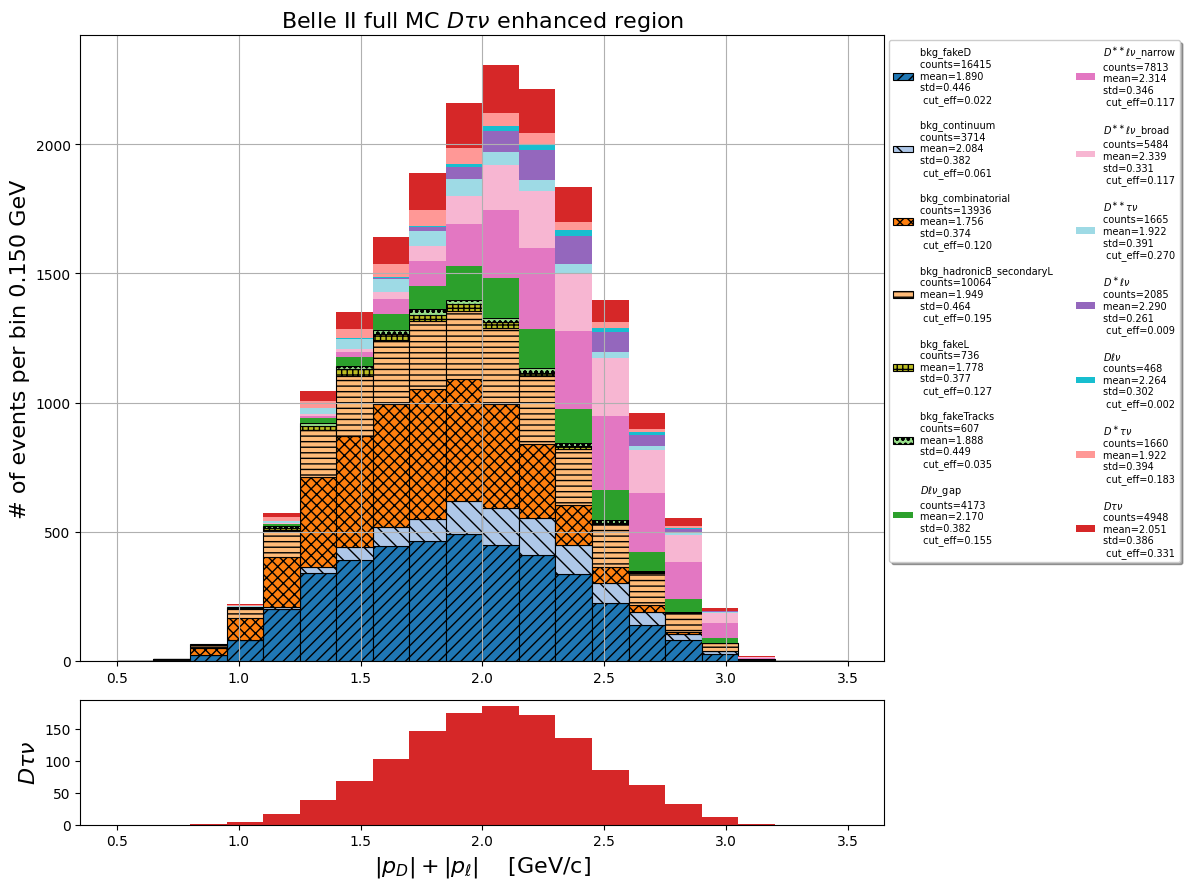

In [12]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(0.5,3.5,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl_mc.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,mask=[],
    cut=f'1.855<D_M<1.885 and {lgb_tight} and 1.7<B0_recMissM2<7.5 and 3<B0_recQ2BhSimple and (DstVeto_massDiff_0<0.135 or 0.145<DstVeto_massDiff_0)',
    figsize=(12,9),legend_nc=2,legend_fs=7,text_fs=16,bottom_plot=r'$D\tau\nu$',title=r'Belle II full MC $D\tau\nu$ enhanced region',
    weights=weights,apply_eventByEvent_correction=False, eventByEvent_weight_col='ell_BFbrems_Weight')

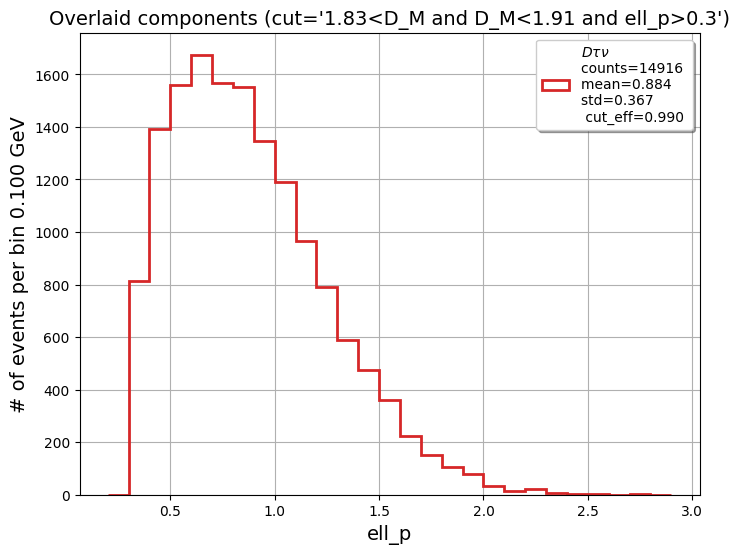

In [12]:
b1 = np.linspace(0.2,2.9,28)
comb_conpon = [r'$D\tau\nu$']
mpl_mc.plot_mc_1d_overlaid(variable='ell_p',bins=b1,mask=[],cut='1.83<D_M and D_M<1.91 and ell_p>0.3',
                        show_only=comb_conpon,density=False,legend_nc=2)

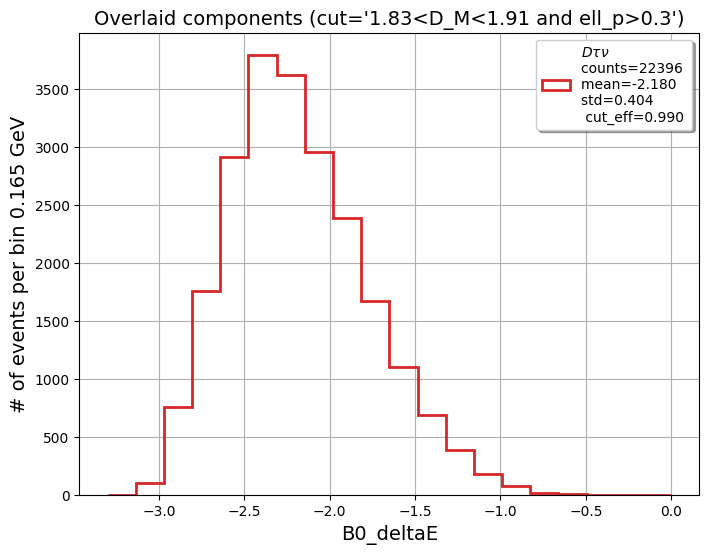

In [16]:
b1 = np.linspace(-3.3,0,21)
comb_conpon = [r'$D\tau\nu$']
mpl_mc.plot_mc_1d_overlaid(variable='B0_deltaE',bins=b1,mask=[],cut='1.83<D_M<1.91 and ell_p>0.3',
                        show_only=comb_conpon,density=False,legend_nc=2)

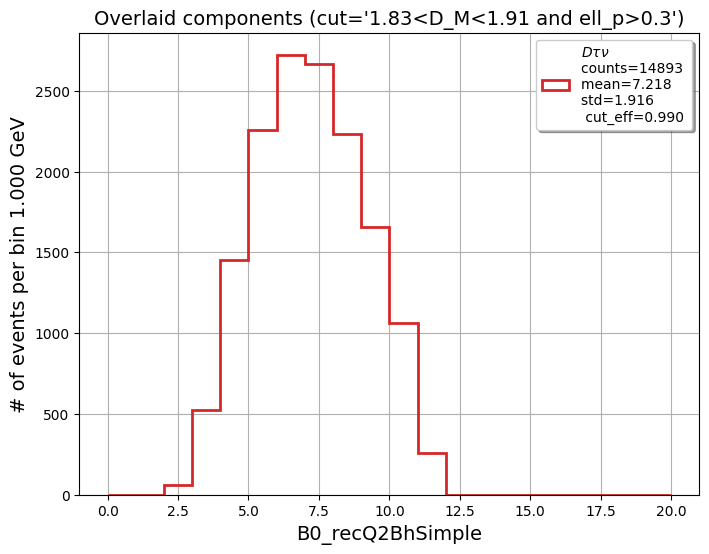

In [22]:
b1 = np.linspace(0,20,21)
comb_conpon = [r'$D\tau\nu$']
mpl_mc.plot_mc_1d_overlaid(variable='B0_recQ2BhSimple',bins=b1,mask=[],cut='1.83<D_M<1.91 and ell_p>0.3',
                        show_only=comb_conpon,density=False,legend_nc=2)

# Control regions
## 0. D_M sidebands

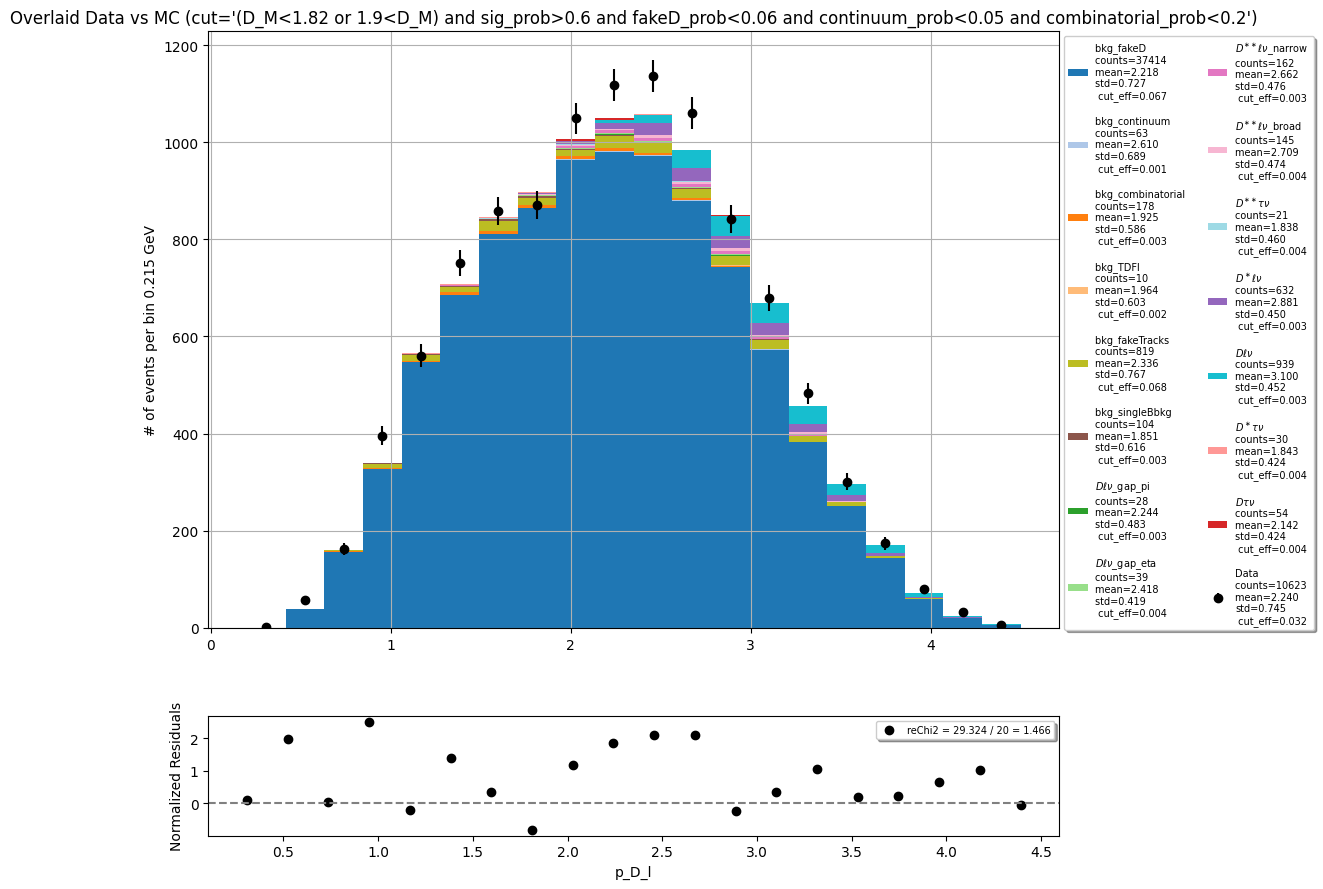

In [53]:
# old sample, old plot
b1 = np.linspace(0.2,4.5,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut=f'(D_M<1.82 or 1.9<D_M) and {lgb_tight}',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PID_weight')

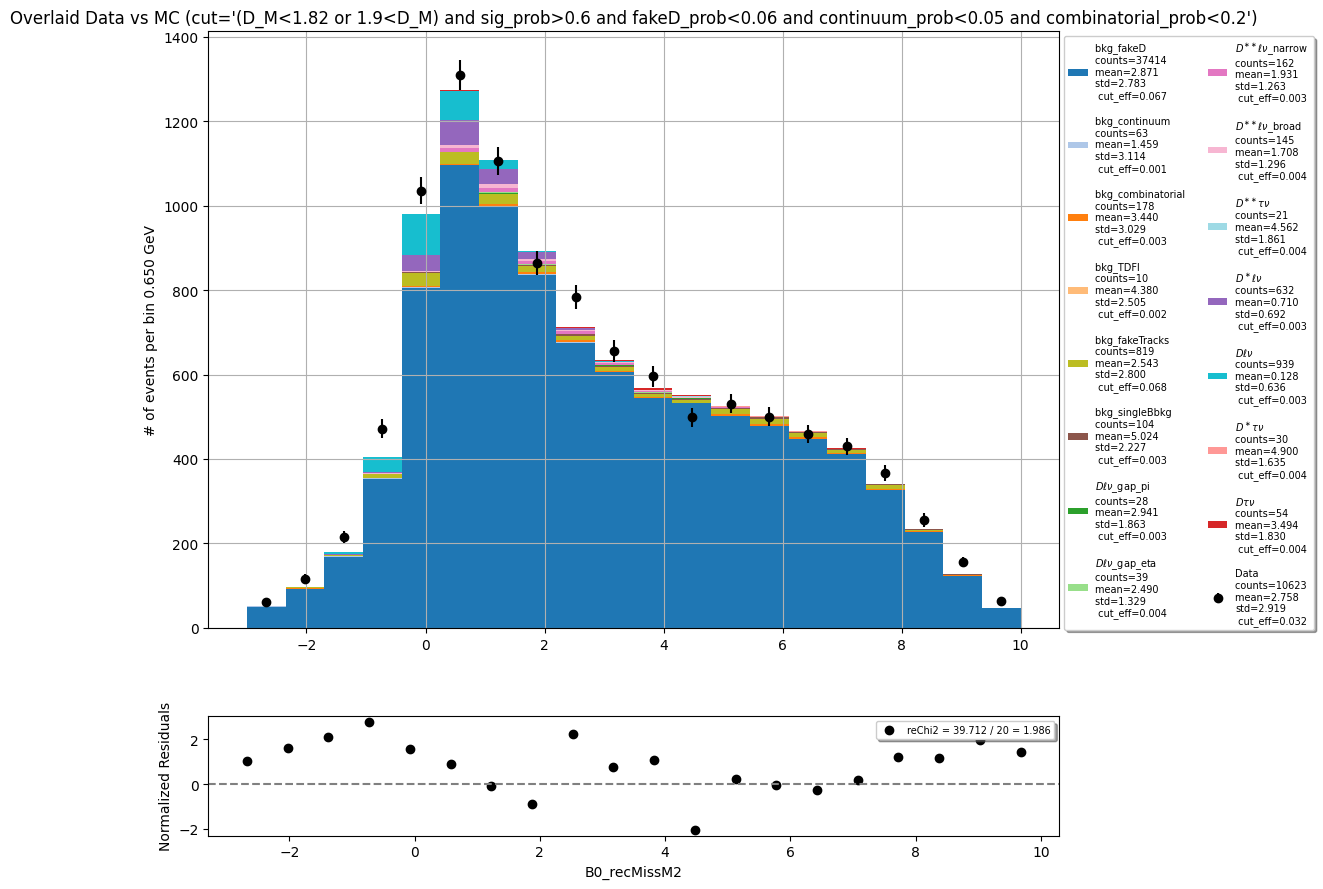

In [54]:
# old sample, old plot
b1 = np.linspace(-5,10,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut=f'(D_M<1.82 or 1.9<D_M) and {lgb_tight}',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PID_weight')

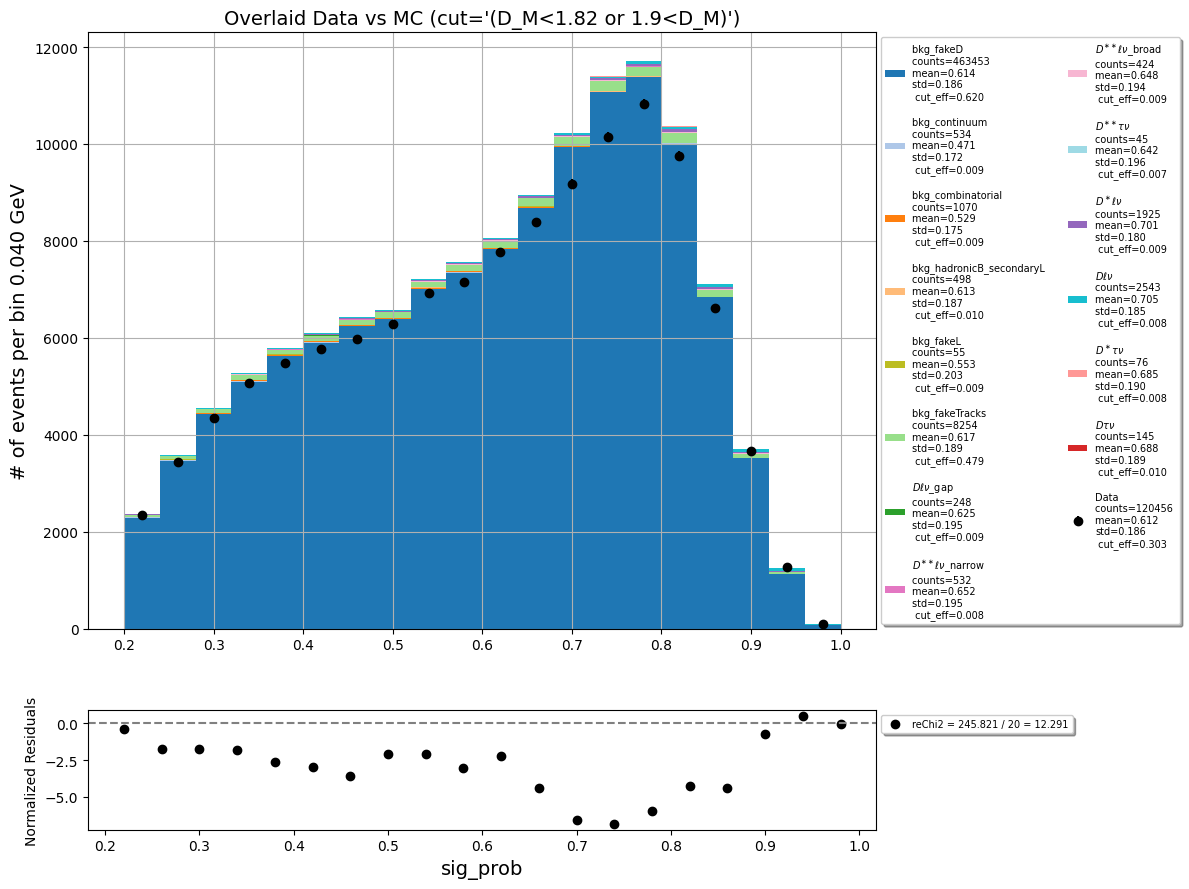

In [22]:
# new sample, new plot
b1 = np.linspace(0.2,1,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='sig_prob',bins=b1,cut=f'(D_M<1.82 or 1.9<D_M)',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= (D_M<1.82 or 1.9<D_M) and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6


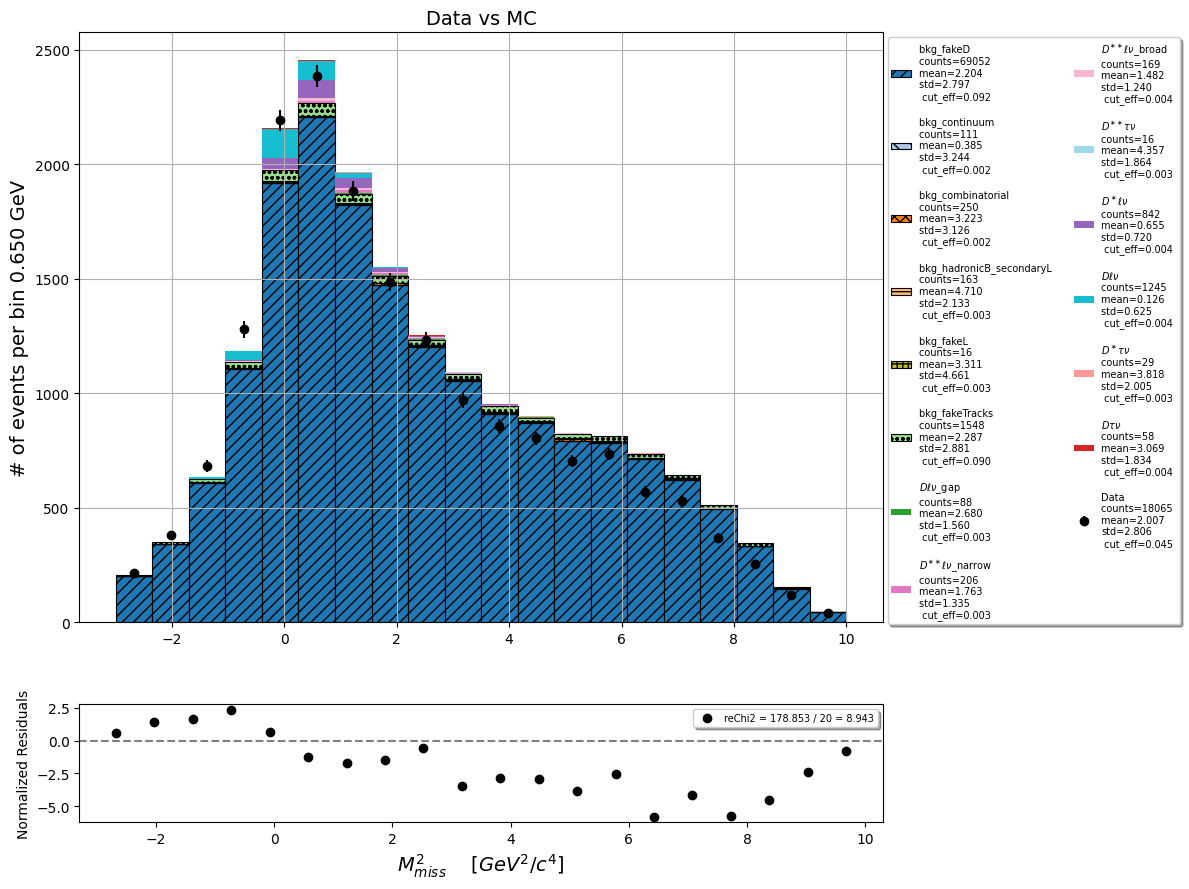

In [3]:
# new sample, new plot
b1 = np.linspace(-3,10,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut=f'(D_M<1.82 or 1.9<D_M) and {lgb_tight}',mask=[],
    figsize=(12,9),legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= (D_M<1.82 or 1.9<D_M) and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6


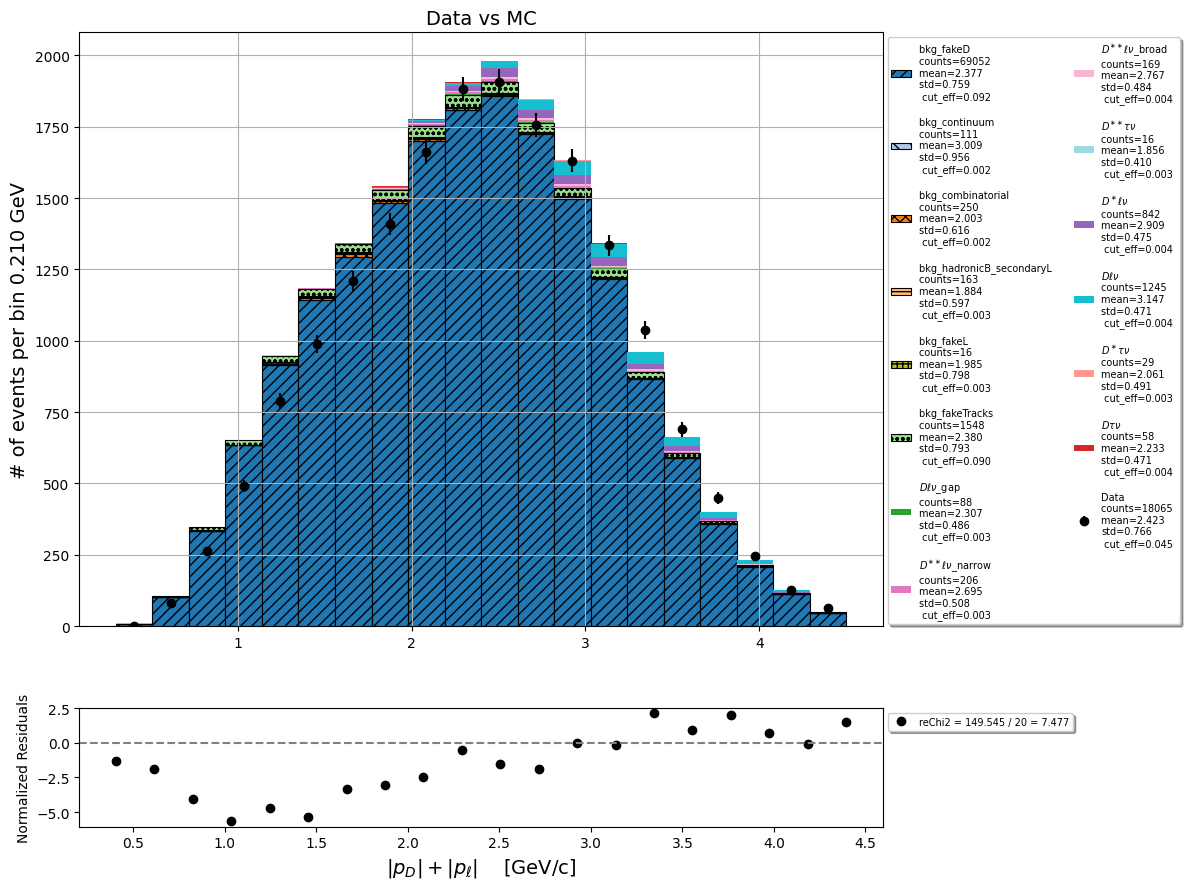

In [4]:
# new sample, new plot
b1 = np.linspace(0.3,4.5,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut=f'(D_M<1.82 or 1.9<D_M) and {lgb_tight}',mask=[],
    figsize=(12,9),legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

## 1. q^2 < 3

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.855<D_M<1.885


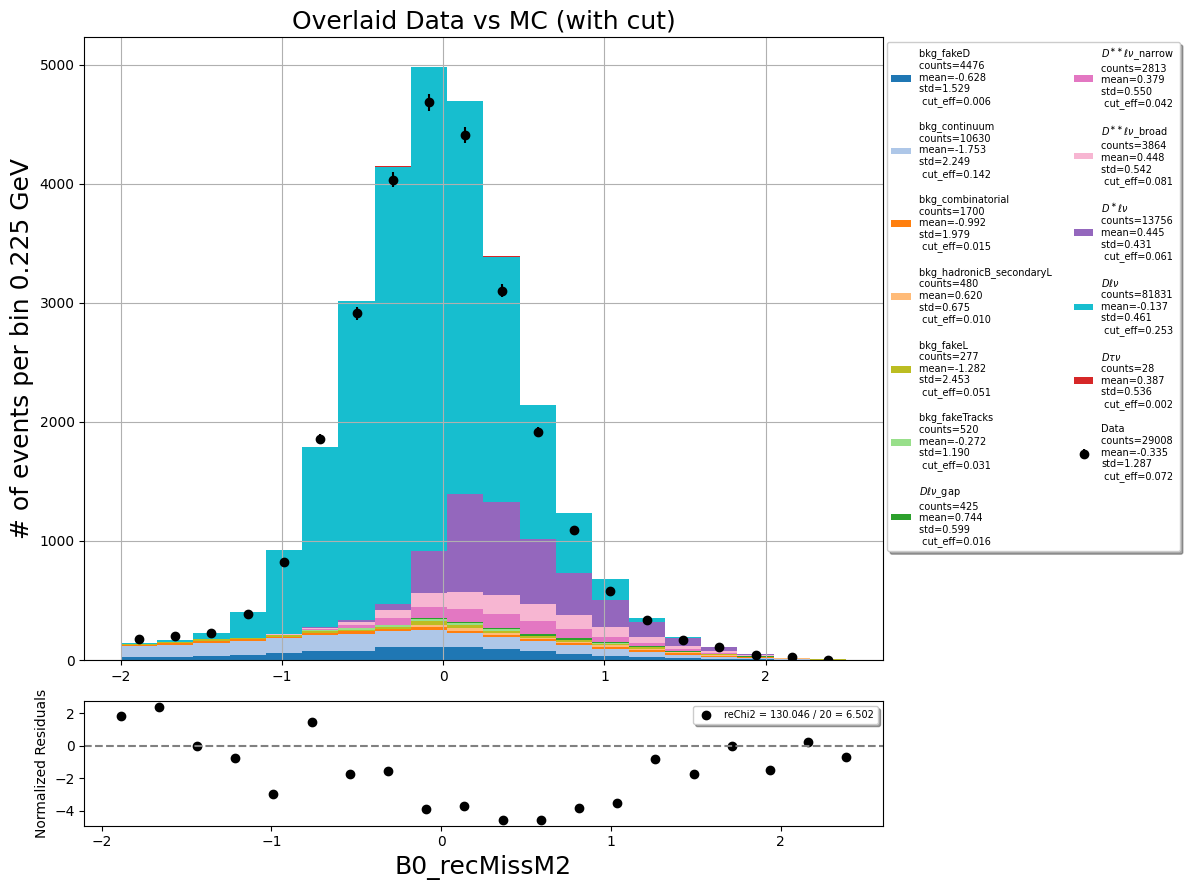

In [13]:
# new sample, new plot, new BDT
b1 = np.linspace(-2,2.5,21)
weights={'all_mc':0.25 * 1.038,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights, text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and -1.5<B0_recMissM2<-0.2 and 1.855<D_M<1.885


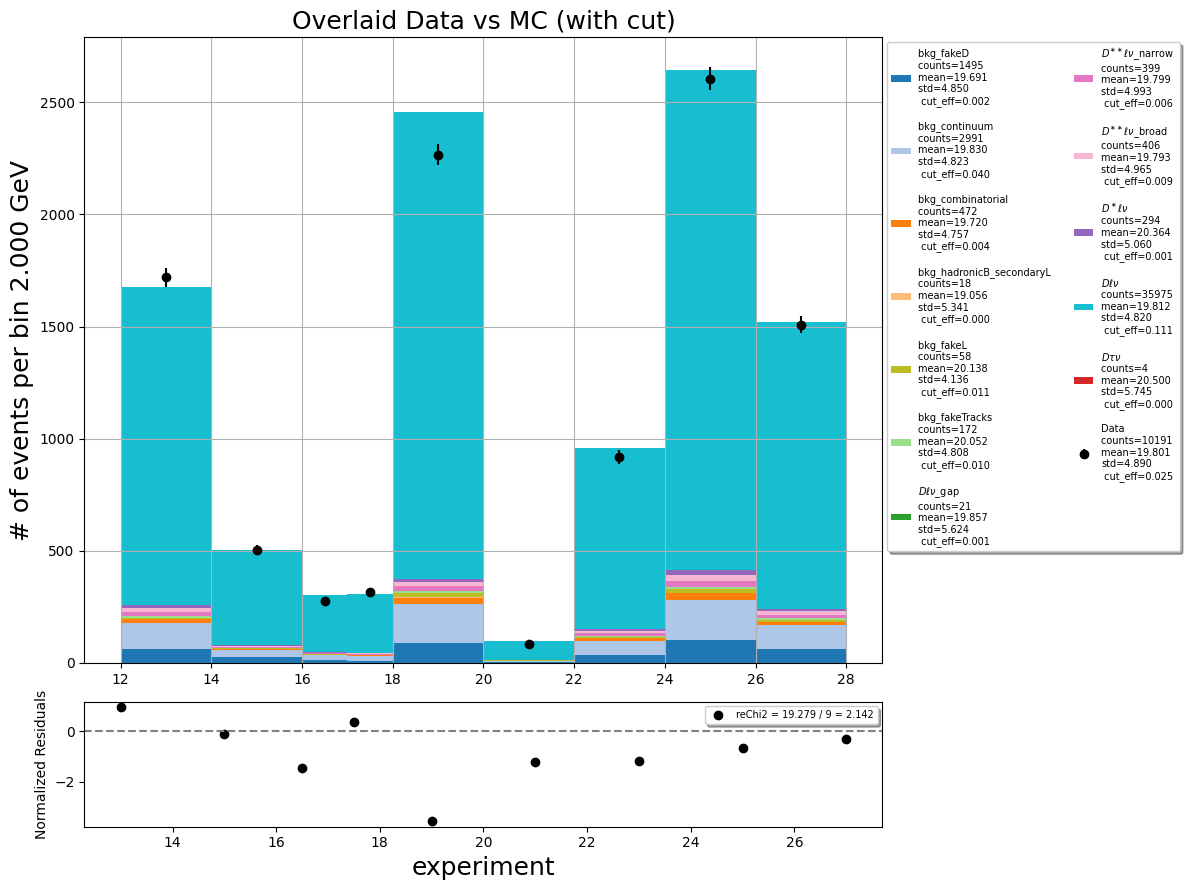

In [6]:
# new sample, new plot, new BDT
b1 = np.array([12,14,16,17,18,20,22,24,26,28])
weights={'all_mc':0.25 * 1.038,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='experiment',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and -1.5<B0_recMissM2<-0.2 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights, text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

In [9]:
# n_generated = np.array([2374566, 726593, 453889, 472552, 3611657, 165268, 1413081, 3776830, 2416480]) * 0.25 * 0.0938
# eff_mc = mc_hist_all / n_generated
# eff_data = data_hist_all / (n_generated * 1.038)

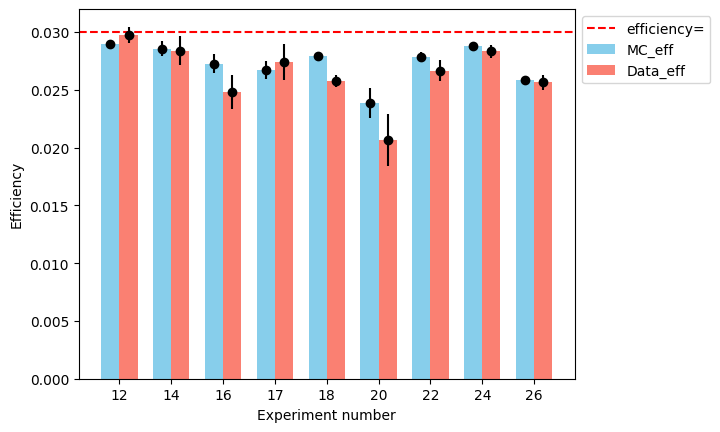

In [10]:
labels = ['12', '14', '16', '17', '18', '20', '22', '24', '26']

x = np.arange(len(labels))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots()
# Plot each group with a different color and shifted position
rects1 = ax.bar(x - width/2, [eff.n for eff in eff_mc], width, label='MC_eff', color='skyblue')
err1   = ax.errorbar(x=x - width/2, y=[eff.n for eff in eff_mc], yerr=[eff.s for eff in eff_mc], fmt='ok')
rects2 = ax.bar(x + width/2, [eff.n for eff in eff_data], width, label='Data_eff', color='salmon')
err2   = ax.errorbar(x=x + width/2, y=[eff.n for eff in eff_data], yerr=[eff.s for eff in eff_data], fmt='ok')
plt.axhline(y=0.03, color='r', linestyle='--', label='efficiency=')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('Experiment number')
ax.set_ylabel('Efficiency')
ax.legend(bbox_to_anchor=(1,1))
plt.show()

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and experiment==26 and -1.5<B0_recMissM2<-0.2 and 1.855<D_M<1.885


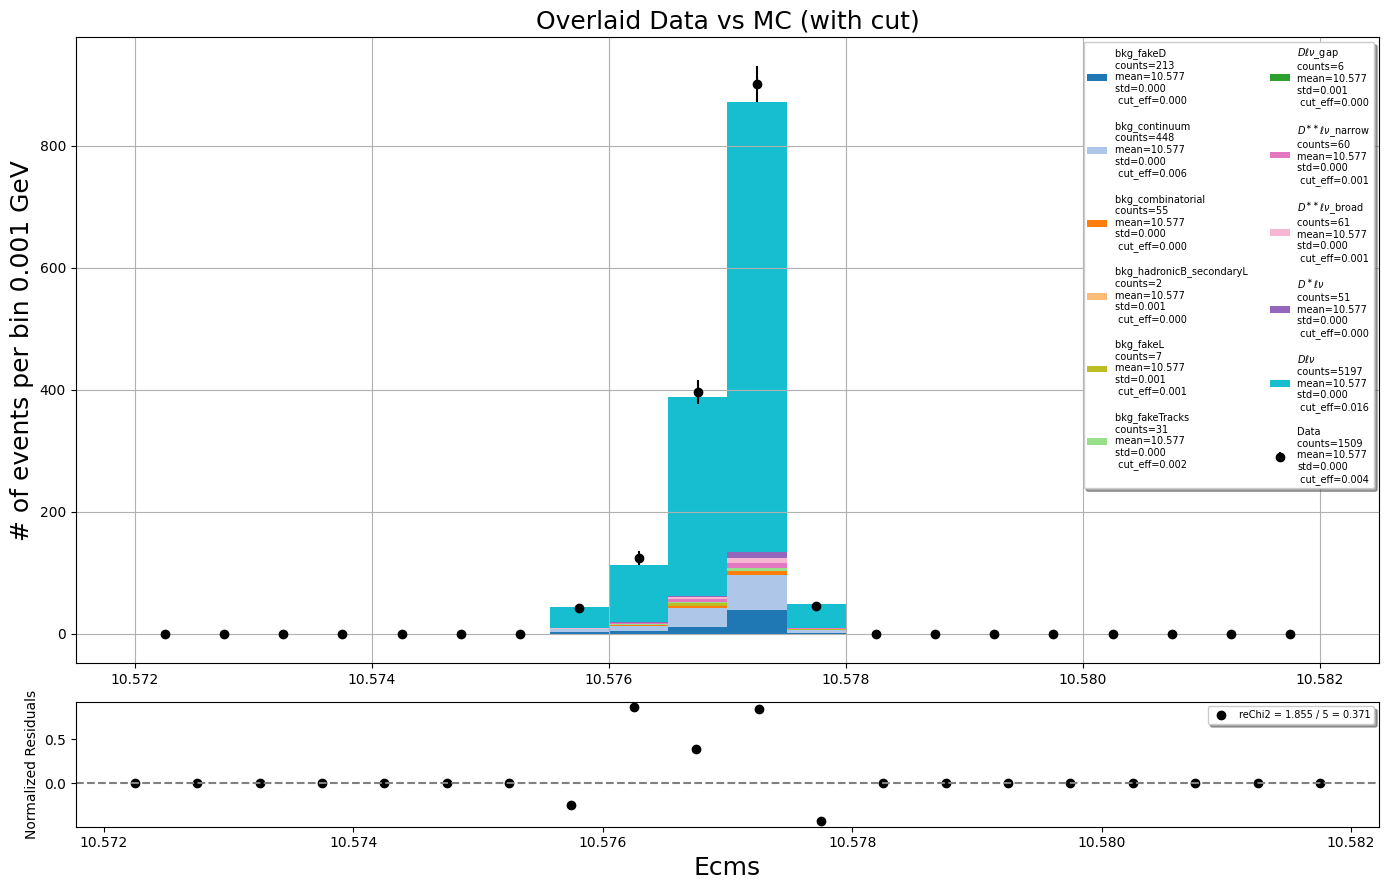

In [10]:
# new sample, new plot
b1 = np.linspace(10.572,10.582,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='Ecms',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and experiment==26 and -1.5<B0_recMissM2<-0.2 and 1.855<D_M<1.885',mask=[],
    figsize=(14,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and experiment==12 and -1.5<B0_recMissM2<-0.2 and 1.855<D_M<1.885


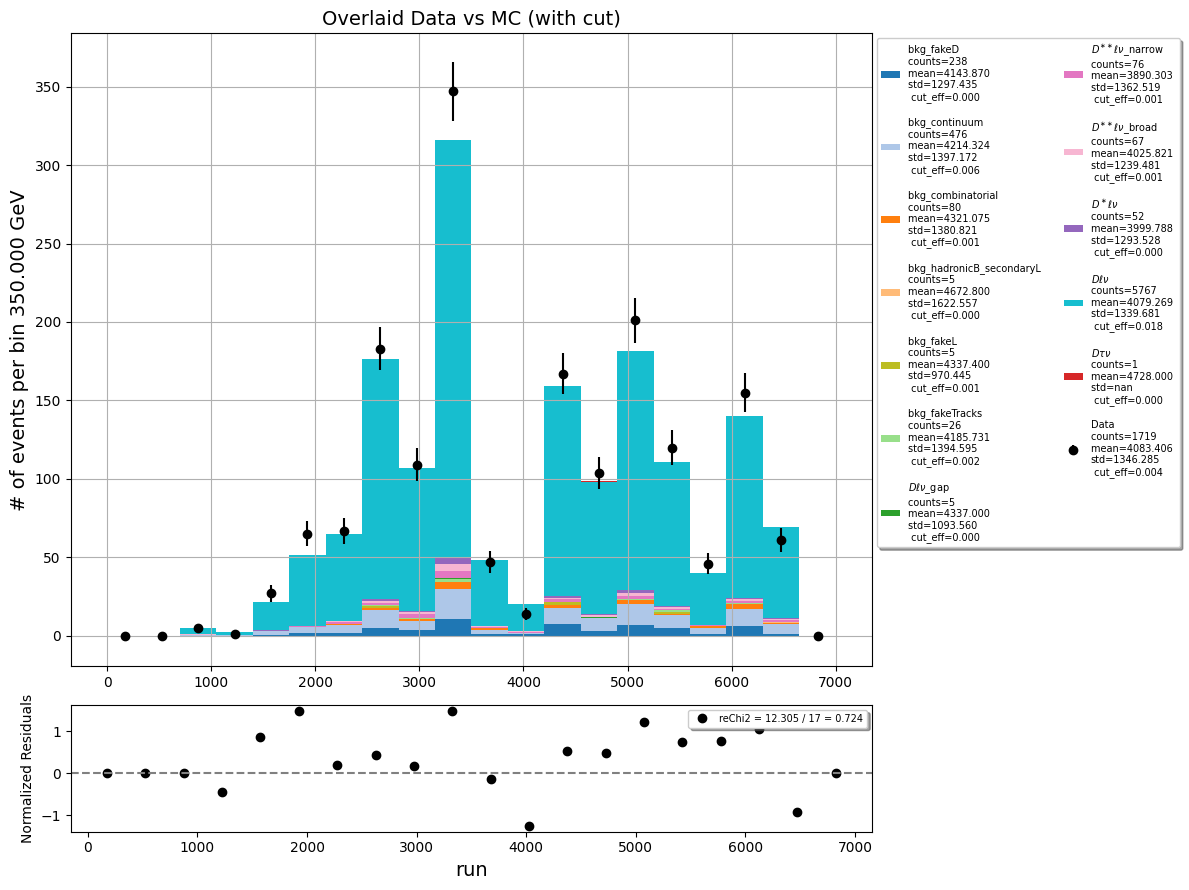

In [11]:
b1 = np.linspace(0,7000,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='run',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and experiment==12 and -1.5<B0_recMissM2<-0.2 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and experiment==18 and -1.5<B0_recMissM2<-0.2 and 1.855<D_M<1.885


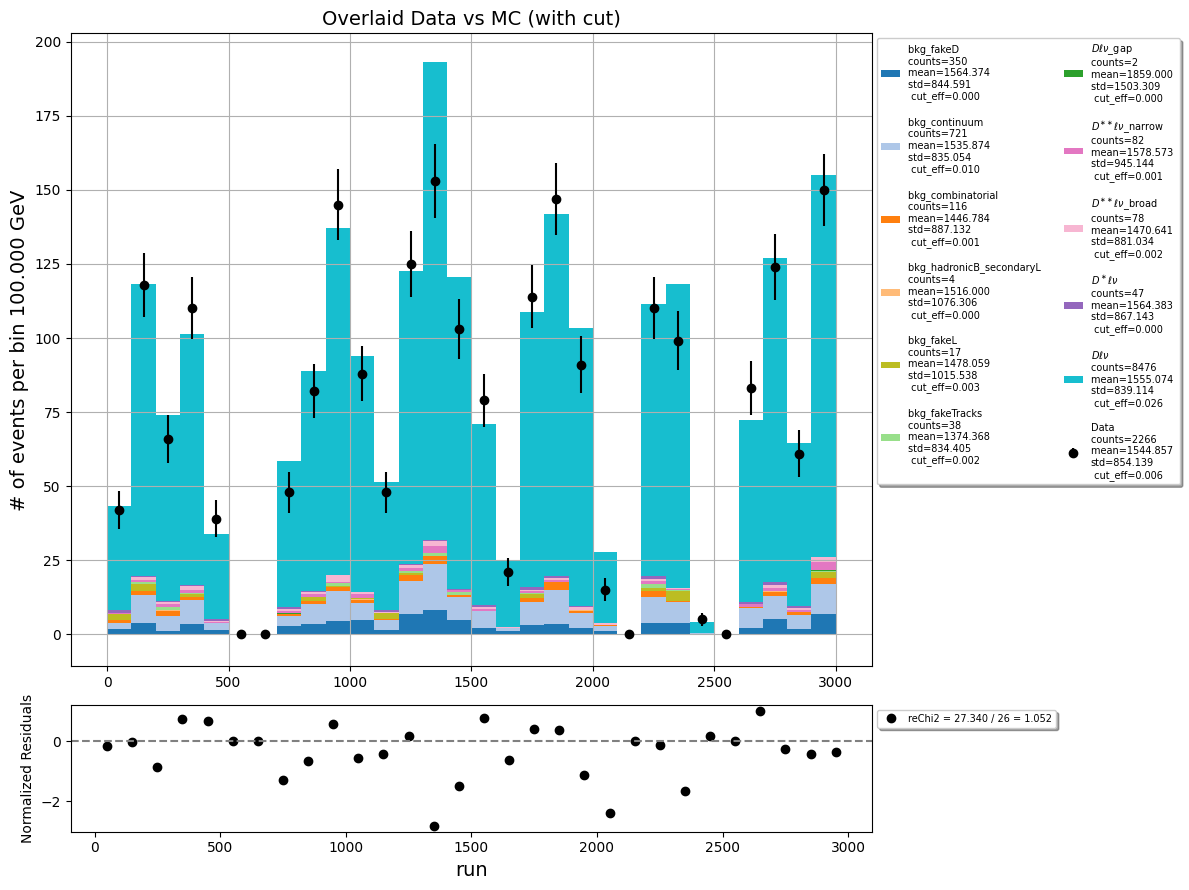

In [12]:
b1 = np.linspace(0,3000,31)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='run',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and experiment==18 and -1.5<B0_recMissM2<-0.2 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and -1.5<B0_recMissM2<-0.2 and 1.855<D_M<1.885


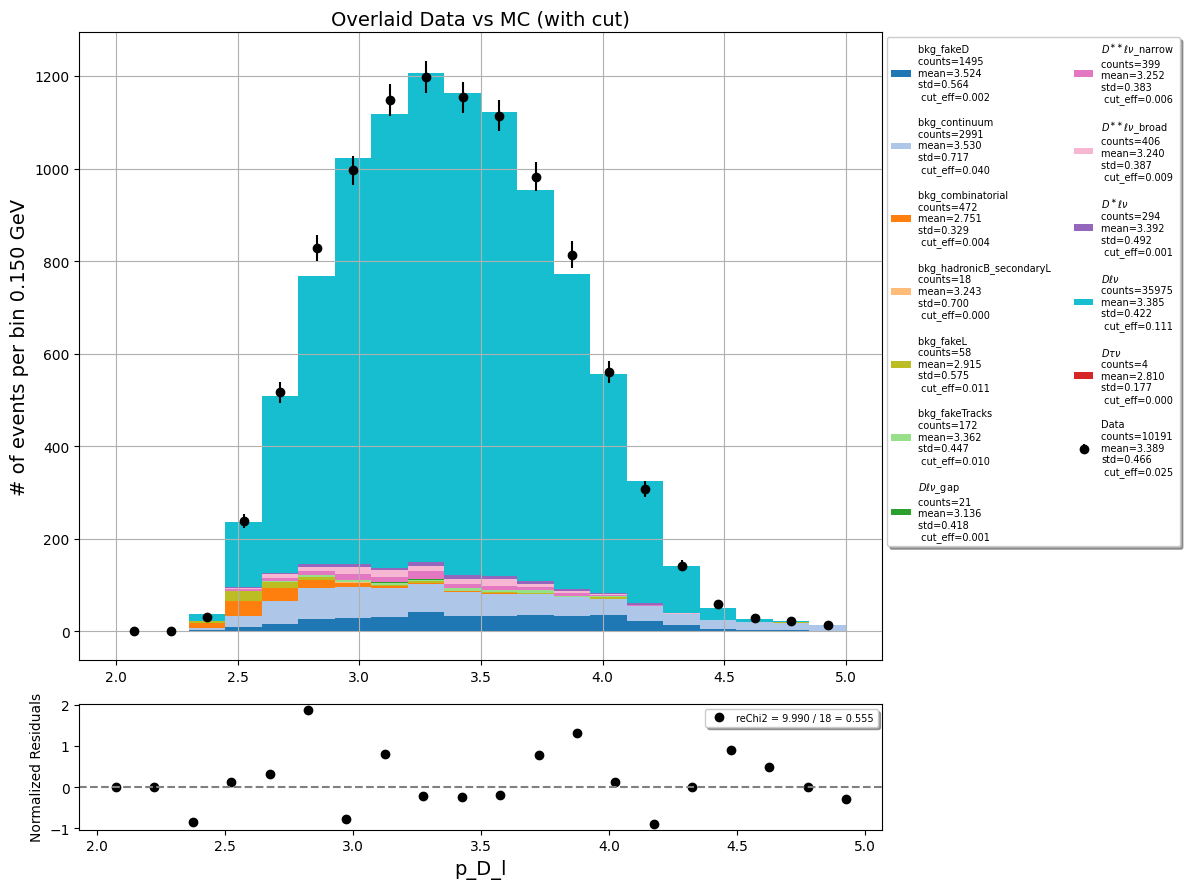

In [13]:
# new sample, new plot, exp<18
b1 = np.linspace(2,5,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and -1.5<B0_recMissM2<-0.2 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and -1.5<B0_recMissM2<-0.2 and 1.855<D_M<1.885


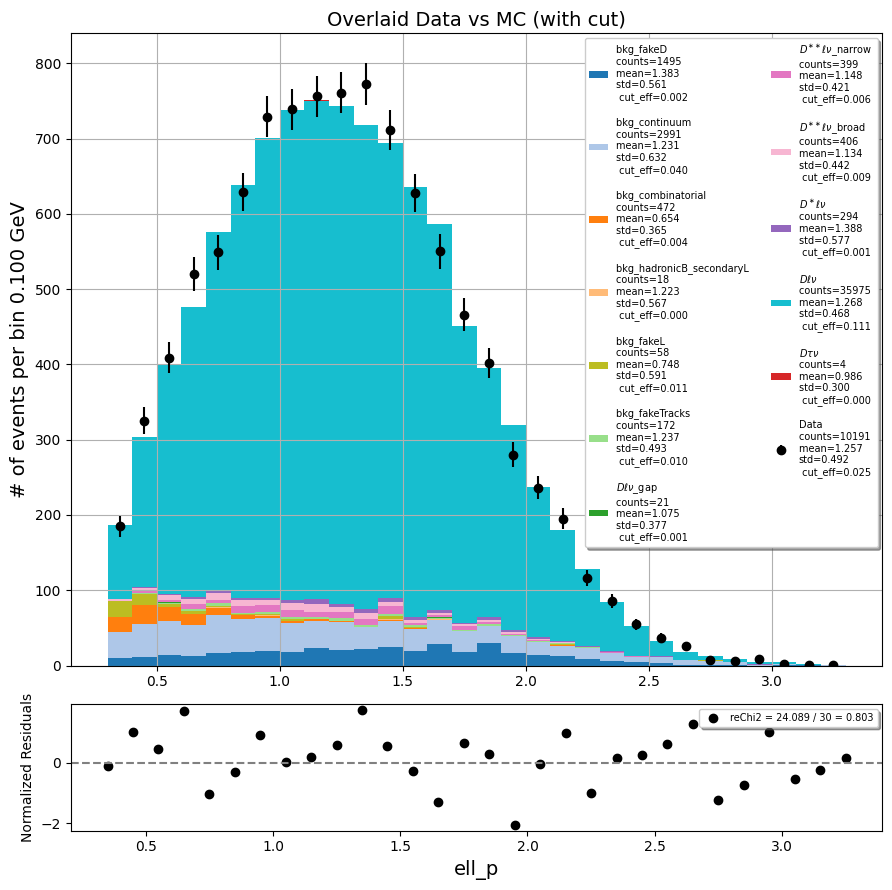

In [14]:
# new sample, new plot, exp<18
b1 = np.linspace(0.3,3.3,31)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='ell_p',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and -1.5<B0_recMissM2<-0.2 and 1.855<D_M<1.885',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

cut= B0_recQ2BhSimple<3 and 1.855<D_M<1.885 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and -1.5<B0_recMissM2<-0.2


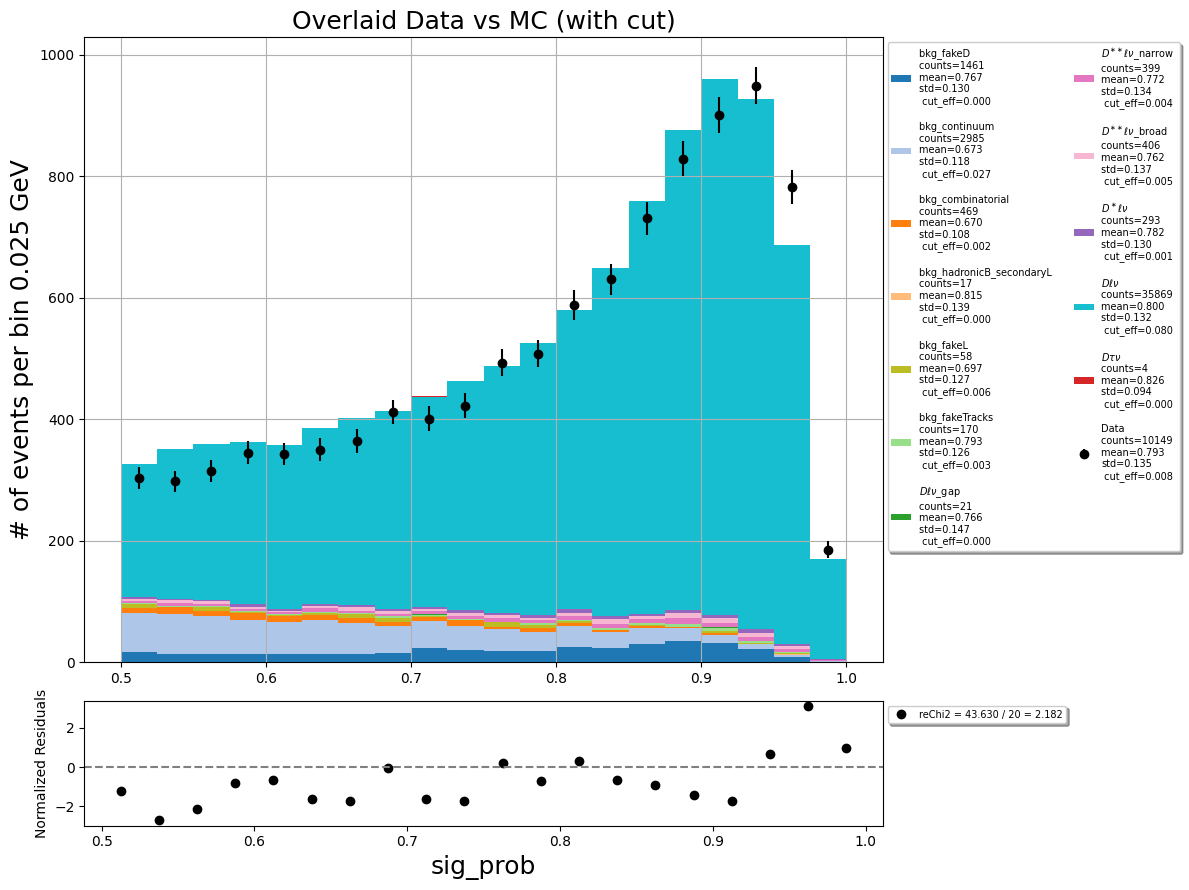

In [37]:
# new sample, new plot
b1 = np.linspace(0.5,1,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='sig_prob',bins=b1,cut=f'B0_recQ2BhSimple<3 and 1.855<D_M<1.885 and {lgb_tight} and -1.5<B0_recMissM2<-0.2',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights, text_fs=18,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= B0_recQ2BhSimple<3 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and -1.5<B0_recMissM2<-0.2


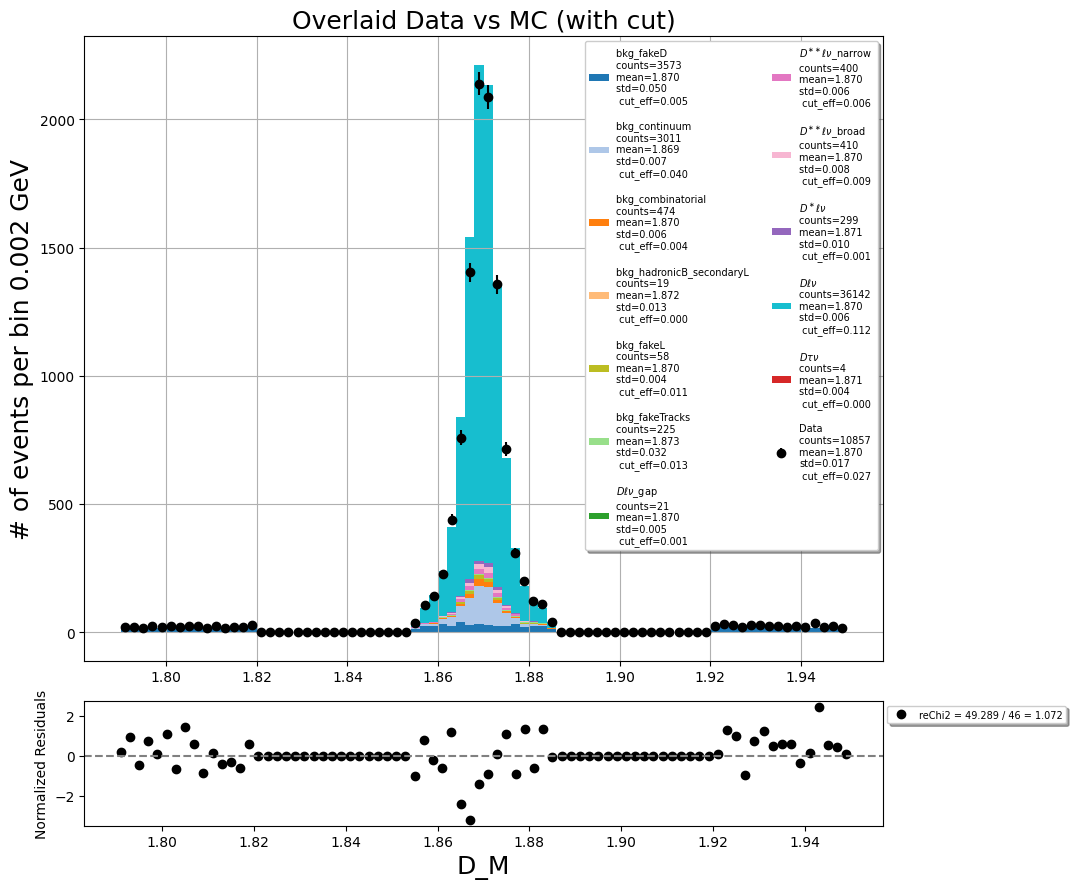

In [9]:
b1 = np.linspace(1.79,1.95,81)
weights={'all_mc':0.25 * 1.038,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='D_M',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight} and -1.5<B0_recMissM2<-0.2',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight')

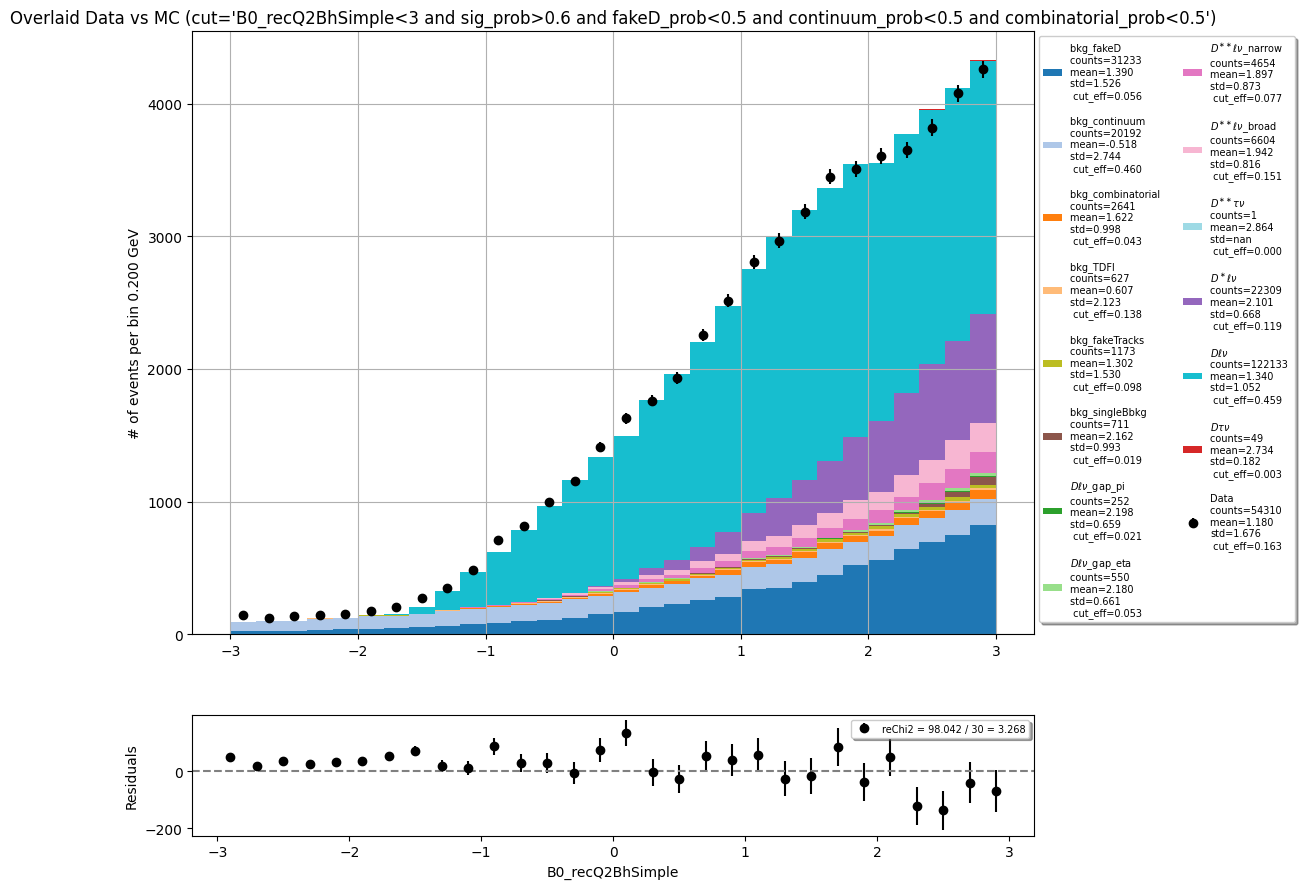

In [8]:
# showing the fake D and sidebands in D_M
b1 = np.linspace(-3,3,21)
weights={'all_mc':0.25}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='B0_recQ2BhSimple',bins=b1,cut=f'B0_recQ2BhSimple<3 and {lgb_tight}',correction=False,mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights)

### 1.1 Fit

In [10]:
# Create the bin edges
p_D_l_bins = np.concatenate(([0.4, 0.6, 0.8], 
                             np.linspace(1,3,41), 
                             [3.1, 3.2, 3.3, 3.4, 3.6, 3.8, 4, 4.2, 4.4, 4.6, 4.8]))

# Create the bin edges
MM2_bins = np.concatenate((np.linspace(-2.5,2.5,11), np.linspace(2.8,10,31) ) )

MM2_bins_sb = np.linspace(-2.5,10,21)
p_D_l_bins_sb = np.linspace(0.4,4.8,21)

# create templates
df_mc_4S_q2SB = df_mc_4S_loose.query(f'B0_recQ2BhSimple<3 and {lgb_tight}')
df_data_4S_q2SB = df_data_4S_loose.query(f'B0_recQ2BhSimple<3 and {lgb_tight}')
samples_q2SB=util.classify_mc_dict(df_mc_4S_q2SB, 'e', template=False)

In [11]:
## MC16rd e
temp_data_e_sr,temp_data_e_sb,temp_data_e_sr_merged, temp_data_e_sb_merged = util.create_templates_new(
                    samples=samples_q2SB,
                    variables=['B0_recMissM2','p_D_l'], bin_threshold=10,merge_threshold=5,
                    bins_sr=[MM2_bins, p_D_l_bins], scale_lumi=1,
                    bins_sb=[MM2_bins_sb, p_D_l_bins_sb],
                    use_real_data_instead_of_asimov=True, real_data=df_data_4S_q2SB,
                    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_PIDweight',
                    sample_to_exclude=['bkg_other_TDTl','bkg_other_signal',
                                      r'$D\ell\nu$_gap',
                                       # 'bkg_fakeD', 
                                       # 'bkg_continuum',
                #                       r'$D^{\ast\ast}\ell\nu$_broad',
                #                       r'$D^{\ast\ast}\ell\nu$_narrow',
                #                       r'$D\ell\nu$',
                #                       r'$D^\ast\ell\nu$',
                #                       r'$D\tau\nu$', 
                #                       r'$D^\ast\tau\nu$', 
                #                       r'$D^{\ast\ast}\tau\nu$',
                                      #  'bkg_fakeTracks',
                                      # 'bkg_TDFl','bkg_singleBbkg',
                                      # 'bkg_combinatorial',
                                      ],
                    sample_weights={r'$D\ell\nu$_gap':              0,  
                                    r'$D^{\ast\ast}\ell\nu$_broad': 0.25 * 1.435 * 1.038, # 11540 events from 1/ab
                                    r'$D^{\ast\ast}\ell\nu$_narrow':0.25 * 1.038,
                                    r'$D\ell\nu$':                  0.25 * 1.038,
                                    r'$D^\ast\ell\nu$':             0.25 * 1.038,
                                    r'$D\tau\nu$':                  0.25 * 1.038 , 
                                    r'$D^\ast\tau\nu$':             0.25 * 1.038 , 
                                    r'$D^{\ast\ast}\tau\nu$':       0.25 * 0.33 * 1.038,
                                    'bkg_fakeD':                    0.25 * 1.038, # here for signal region
                                    'bkg_TDFl':                     0.25 * 1.038,
                                    'bkg_continuum':                0.25 * 1.038,
                                    'bkg_combinatorial':            0.25 * 1.038,
                                    'bkg_singleBbkg':               0.25 * 1.038,
                                    'bkg_fakeTracks':               0.25 * 1.038,
                                    })

Creating templates for the signal region
Creating templates for D_M sidebands channel
creating new templates with merged bins in the signal region, original template length = 176, new template (merge small bins) length = 176
creating new templates with merged bins in the D mass sidebands, original template length = 50, new template (merge small bins) length = 50


In [14]:
import pyhf
import cabinetry
cabinetry.set_logging()
spec_e_sb = util.create_workspace(temp_data_channels=[temp_data_e_sr, temp_data_e_sb], mc_uncer=True,fakeD_uncer=True)
spec_e_sb['measurements'] = [{"name": "q2_sideband", "config": {"poi": "$D\\ell\\nu$_norm", "parameters": []}}]
model_e_sb, data_e_sb = cabinetry.model_utils.model_and_data(spec_e_sb)

INFO - pyhf.workspace - Validating spec against schema: workspace.json
INFO - pyhf.pdf - Validating spec against schema: model.json
INFO - pyhf.pdf - adding modifier $D\ell\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D\tau\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D^\ast\ell\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D^{\ast\ast}\ell\nu$ + gap_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier bkg_fakeD_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier bkg_continuum_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier mcStat_ch0 (176 new nuisance parameters)
INFO - pyhf.pdf - adding modifier mcStat_ch1 (50 new nuisance parameters)


In [17]:
fit_results = cabinetry.fit.fit(model=model_e_sb, data=data_e_sb,goodness_of_fit=True,
                                fix_pars=[False, True]
                               )

INFO - cabinetry.fit - performing maximum likelihood fit
INFO - cabinetry.fit - Migrad status:
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 926.5                      │             Nfcn = 61924             │
│ EDM = 1.32e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴─────────────────────────────────

INFO - pyhf.workspace - Validating spec against schema: workspace.json
INFO - pyhf.pdf - Validating spec against schema: model.json
INFO - pyhf.pdf - adding modifier $D\ell\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D\tau\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D^\ast\ell\nu$_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier $D^{\ast\ast}\ell\nu$ + gap_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier bkg_fakeD_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier bkg_continuum_norm (1 new nuisance parameters)
INFO - pyhf.pdf - adding modifier mcStat_ch0 (176 new nuisance parameters)
INFO - pyhf.pdf - adding modifier mcStat_ch1 (50 new nuisance parameters)
INFO - cabinetry.visualize.utils - saving figure as figures/modifier_grid.pdf


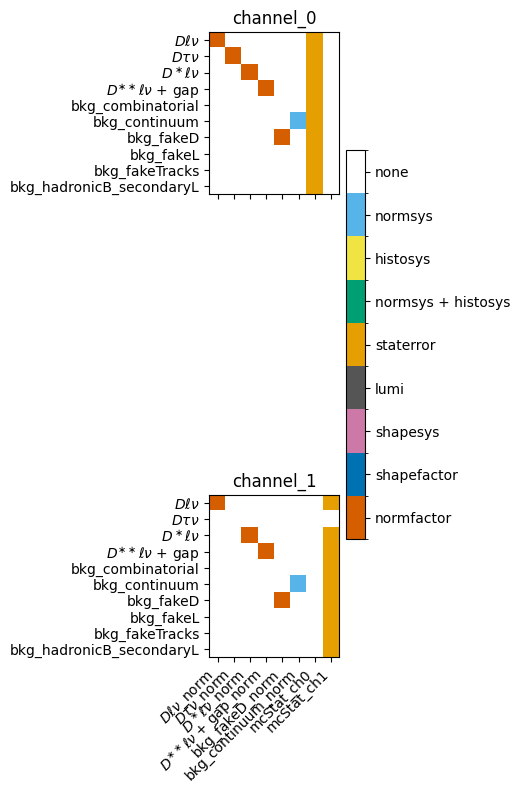

In [15]:
cabinetry.visualize.modifier_grid(pyhf.Workspace(spec_e_sb).model())

In [14]:
fitter = util.fit_Dmass(x_edges=b1, hist=data_hist_all, poly_only=True)
m_ml, c_ml, result_ml = fitter.fit_gauss_poly_ML(deg=1)
m_ml

initial parameters= [ 1.1850e+02  1.8700e+00  2.0000e-02  5.9268e+04  1.8180e+02 -9.3100e+01]


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 27.27 (χ²/ndof = 1.0)      │              Nfcn = 142              │
│ EDM = 3.82e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ x0   │    0.0    │    1.2    │            │            │    0    │         │  yes  │
│ 1 │ x1   │   1.870   │   0.019   │            │            │    0    │         │  yes  │
│ 2 │ x2   │  20.0e-3  │  0.2e-3   │            │            │    0    │         │  yes  │
│ 3 │ x3   │  19.80e3  │  0.23e3   │            │            │         │         │       │
│ 4 │ x4   │   0.1e3   │   0.7e3   │            │            │         │         │       │
│ 5 │ x5   │  -0.06e3  │  0.32e3   │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬───────────────────────────────────────────────────────┐
│    │       x0       x1       x2       x3       x4       x5 │
├────┼───────────────────────────────────────────────────────┤
│ x0 │        0        0        0        0        0        0 │
│ x1 │        0        0        0        0        0        0 │
│ x2 │        0        0        0        0        0        0 │
│ x3 │        0        0        0 5.46e+04        0        0 │
│ x4 │        0        0        0        0 4.63e+05  -0.22e6 │
│ x5 │        0        0        0        0  -0.22e6 1.05e+05 │
└────┴───────────────────────────────────────────────────────┘

In [15]:
yields_left = fitter.poly_integral(xrange=[1.79,1.82],result=result_ml)
yields_sig = fitter.poly_integral(xrange=[1.855,1.885],result=result_ml)
yields_right = fitter.poly_integral(xrange=[1.92,1.95],result=result_ml)

Yields from 1.79 to 1.82 = 3540.042 ± 61.021
Yields from 1.855 to 1.885 = 3713.238 ± 43.813
Yields from 1.92 to 1.95 = 3886.433 ± 62.279


In [17]:
a = len(df_data_4S_loose.query('1.79<D_M<1.82 and B0_recQ2BhSimple<3'))
b = len(df_data_4S_loose.query('1.92<D_M<1.95 and B0_recQ2BhSimple<3'))
print('data', a,b)

data 3532 3881


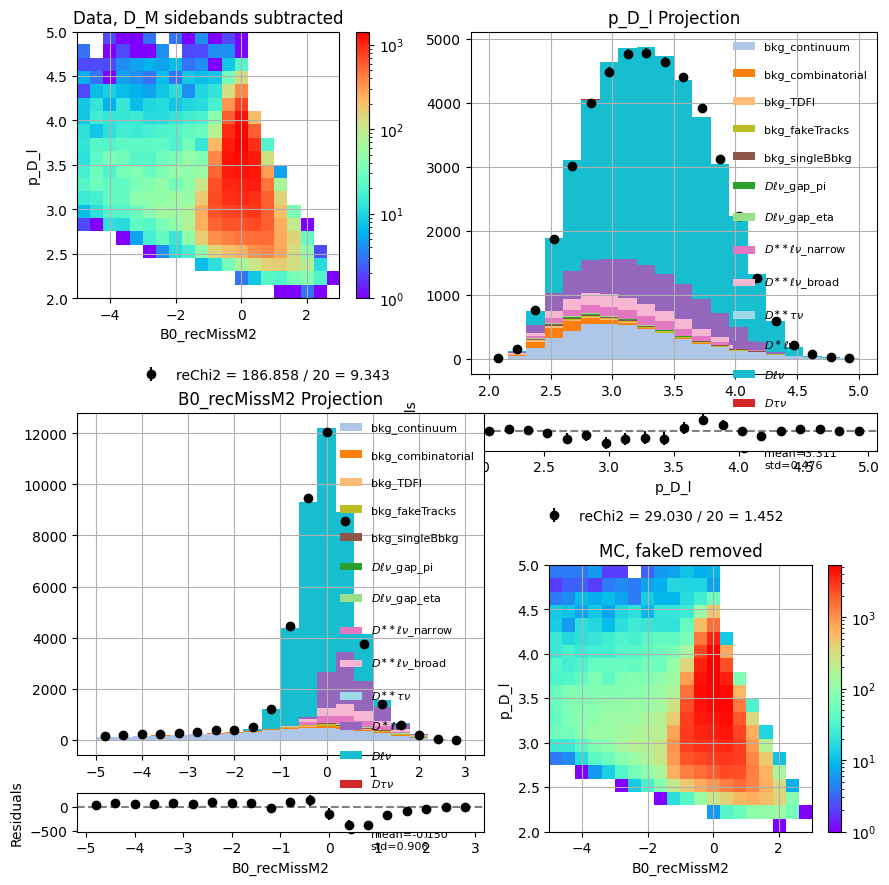

In [21]:
# e channel, lgb_loose
b_mm2 = np.linspace(-5,3,21)
b_pDl = np.linspace(2,5,21)
scale2 = {'data left sideband': 1550/1466/2,
         'data right sideband': 1550/1635/2,
         'data signal region': 1,
         'all_mc': 0.25}

par_dict={'var_list':['B0_recMissM2','p_D_l'],
          'bin_list': [b_mm2, b_pDl],
          'cut': 'B0_recQ2BhSimple<3', #'B0_roeMbc_my_mask>5.1 and -4<B0_roeDeltae_my_mask<1',
          'weights': scale2,
          'correction': False,
          'mask': ['bkg_fakeD']}
indices_threshold, temp_data = mpl.plot_data_subtracted_and_mc(**par_dict)

## 2. D* veto

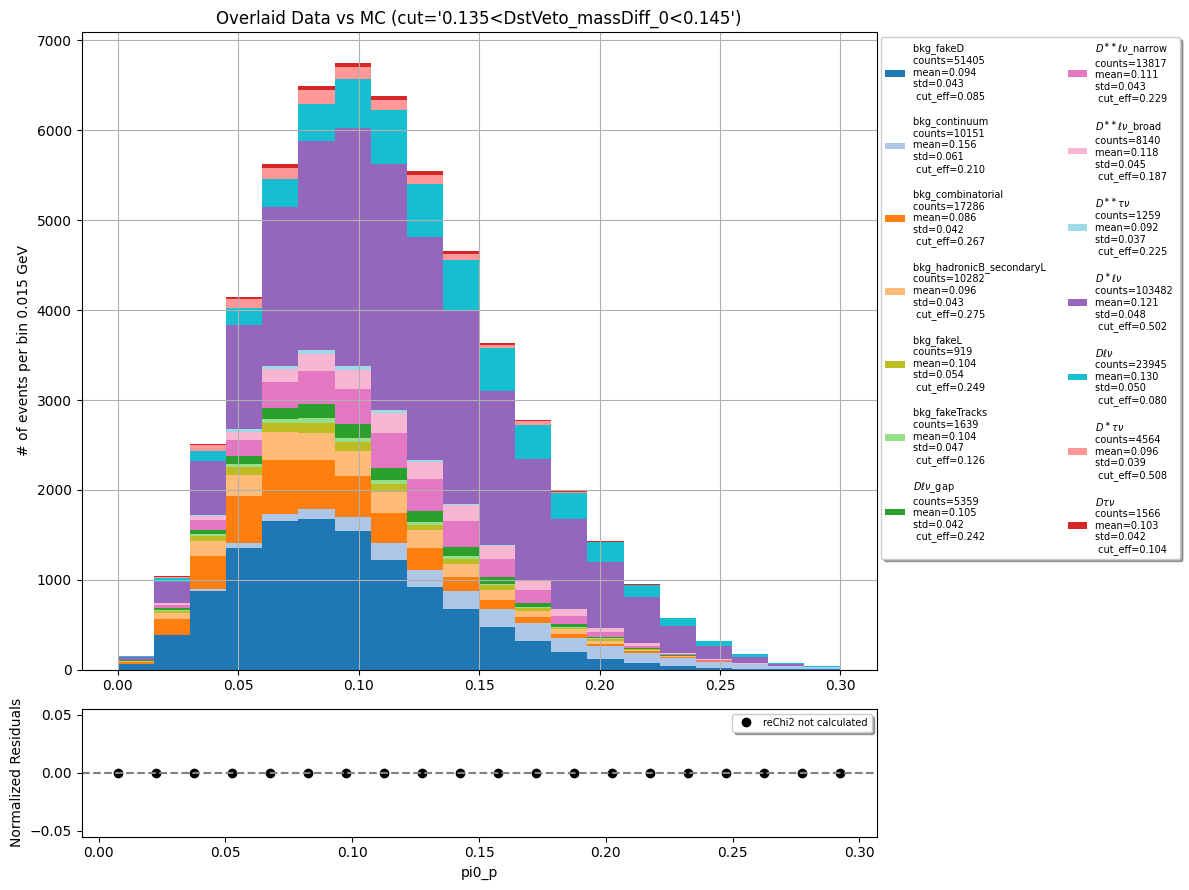

In [48]:
# e
b1 = np.linspace(0,0.3,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.9, r'$D^{\ast\ast}\ell\nu$_narrow':0.25*0.7,r'$D^{\ast\ast}\ell\nu$_broad':0.25*0.7,
        # 'bkg_singleBbkg':0.25*0.5, 'bkg_combinatorial':0.25*0.5}
data_hist_all, mc_hist_all = mpl_mc.plot_data_mc_stacked(
    variable='pi0_p',bins=b1,cut='0.135<DstVeto_massDiff_0<0.145',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight')

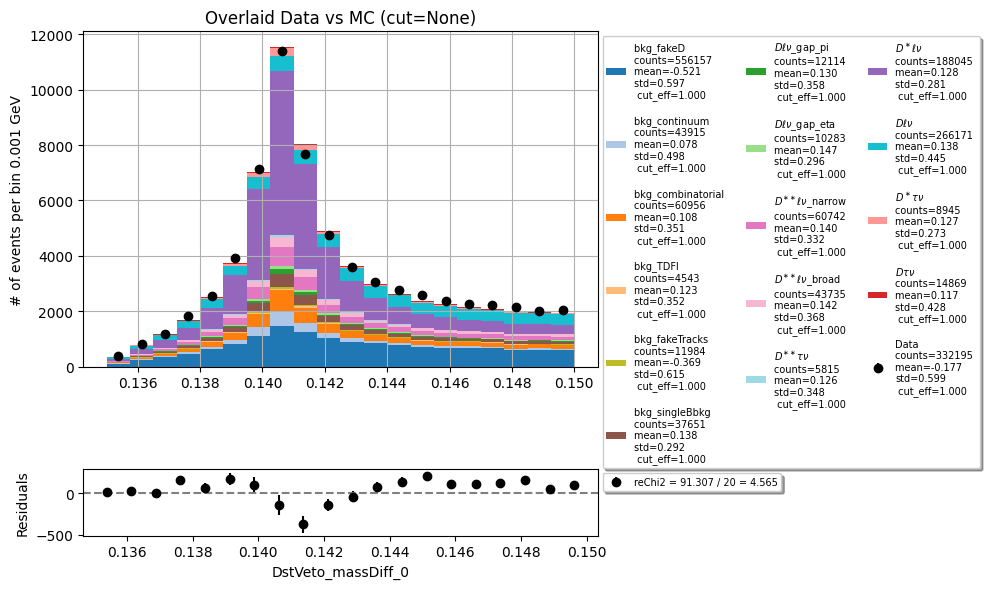

In [51]:
# e channel
b1 = np.linspace(0.135,0.15,21)
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='DstVeto_massDiff_0',bins=b1,cut=None,
    correction=False,mask=[],figsize=(10,6),ratio=False,
    weights={'all_mc':0.22},legend_nc=3, legend_fs=7)

cut= sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 0<B0_recMissM2<3 and 1.855<D_M<1.885 and 0.135<DstVeto_massDiff_0<0.145


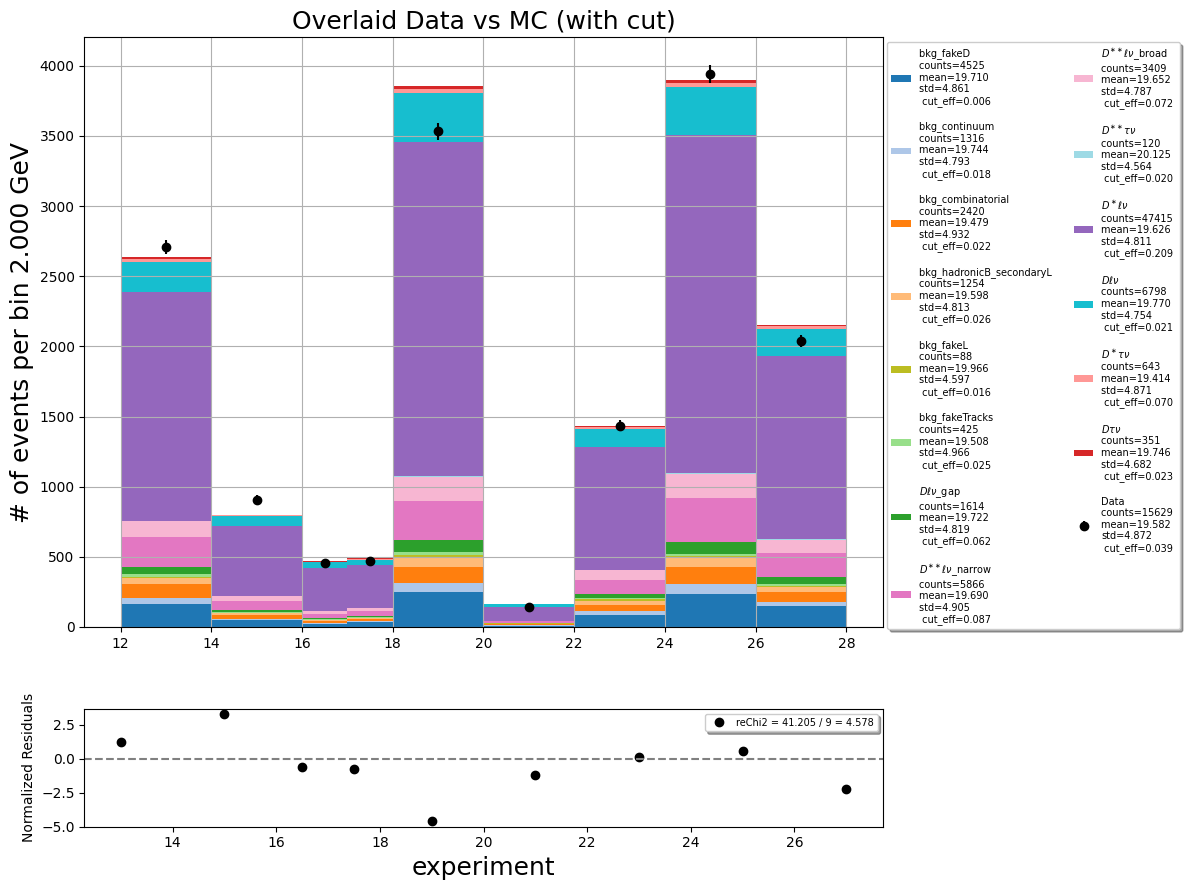

In [16]:
# new sample, new plot, new BDT
b1 = np.array([12,14,16,17,18,20,22,24,26,28])
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='experiment',bins=b1,cut=f'{lgb_tight} and 0<B0_recMissM2<3 and 1.855<D_M<1.885 and 0.135<DstVeto_massDiff_0<0.145',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights, text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight')

cut= 0.135<DstVeto_massDiff_0<0.145 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.855<D_M<1.885 and experiment<18


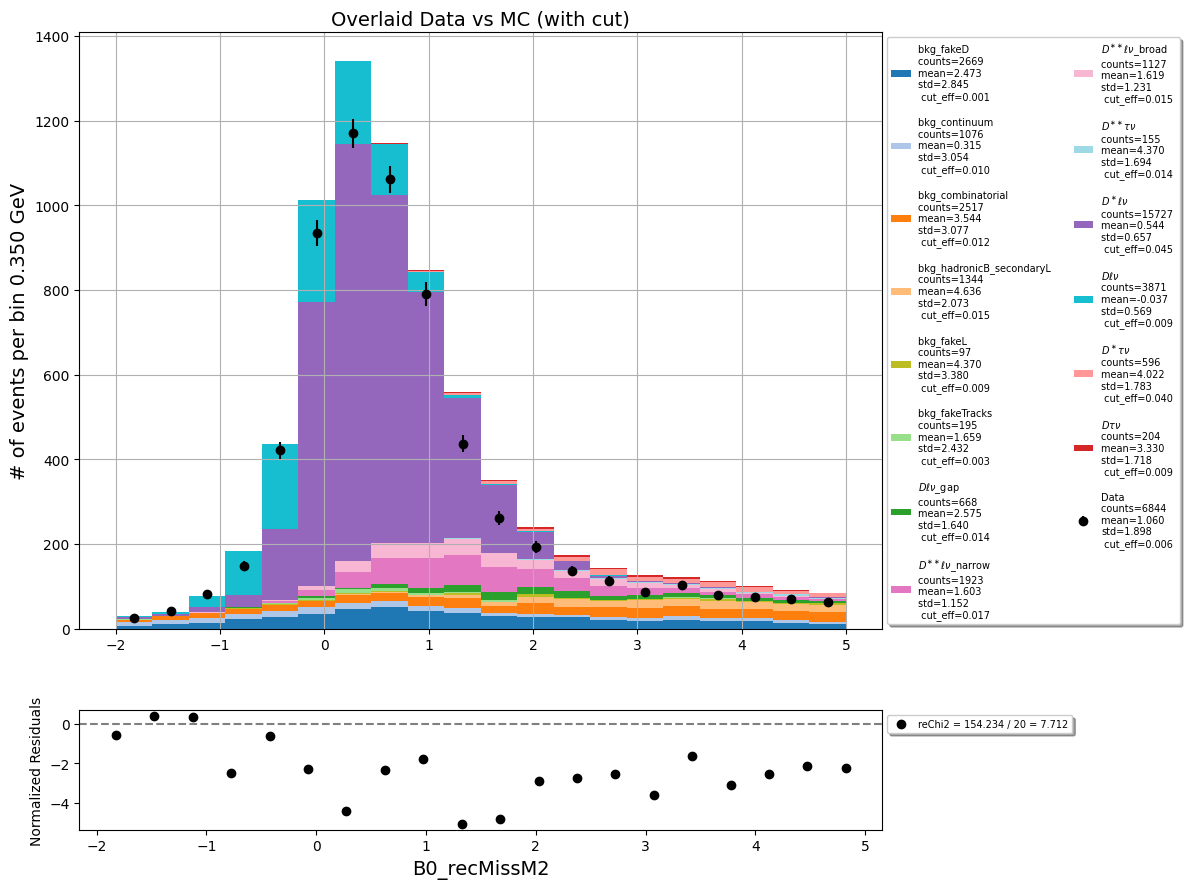

In [59]:
# exp<18
b1 = np.linspace(-2,5,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.9, r'$D^{\ast\ast}\ell\nu$_narrow':0.25*0.7,r'$D^{\ast\ast}\ell\nu$_broad':0.25*0.7,
        # 'bkg_singleBbkg':0.25*0.5, 'bkg_combinatorial':0.25*0.5}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut=f'0.135<DstVeto_massDiff_0<0.145 and {lgb_tight} and 1.855<D_M<1.885 and experiment<18',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
apply_eventByEvent_correction=True, eventByEvent_weight_col='ell_BFbrems_Weight')

cut= 0.135<DstVeto_massDiff_0<0.145 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.855<D_M<1.885 and experiment<18


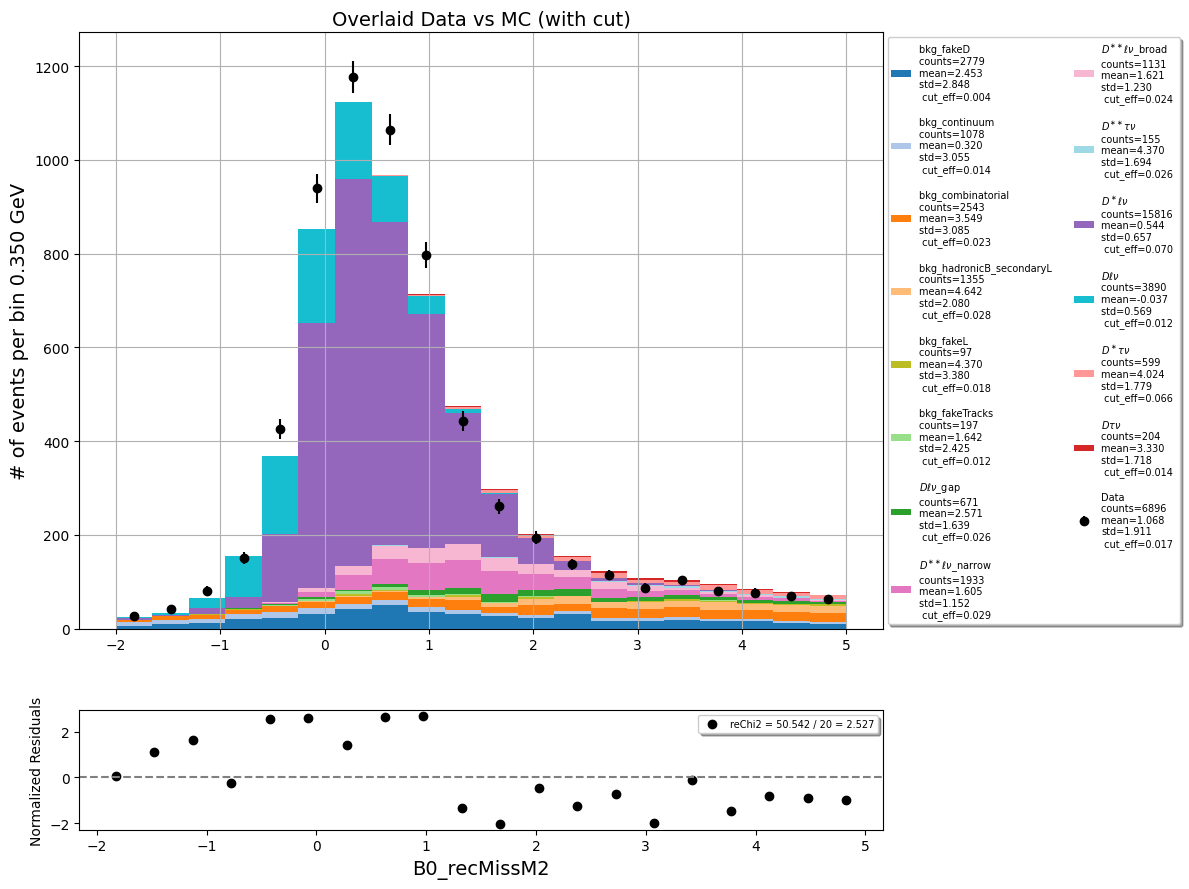

In [17]:
# exp<18
b1 = np.linspace(-2,5,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.9, r'$D^{\ast\ast}\ell\nu$_narrow':0.25*0.7,r'$D^{\ast\ast}\ell\nu$_broad':0.25*0.7,
        # 'bkg_singleBbkg':0.25*0.5, 'bkg_combinatorial':0.25*0.5}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='B0_recMissM2',bins=b1,cut=f'0.135<DstVeto_massDiff_0<0.145 and {lgb_tight} and 1.855<D_M<1.885 and experiment<18',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
    apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight')

cut= 0.135<DstVeto_massDiff_0<0.145 and sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 1.855<D_M<1.885 and experiment<18


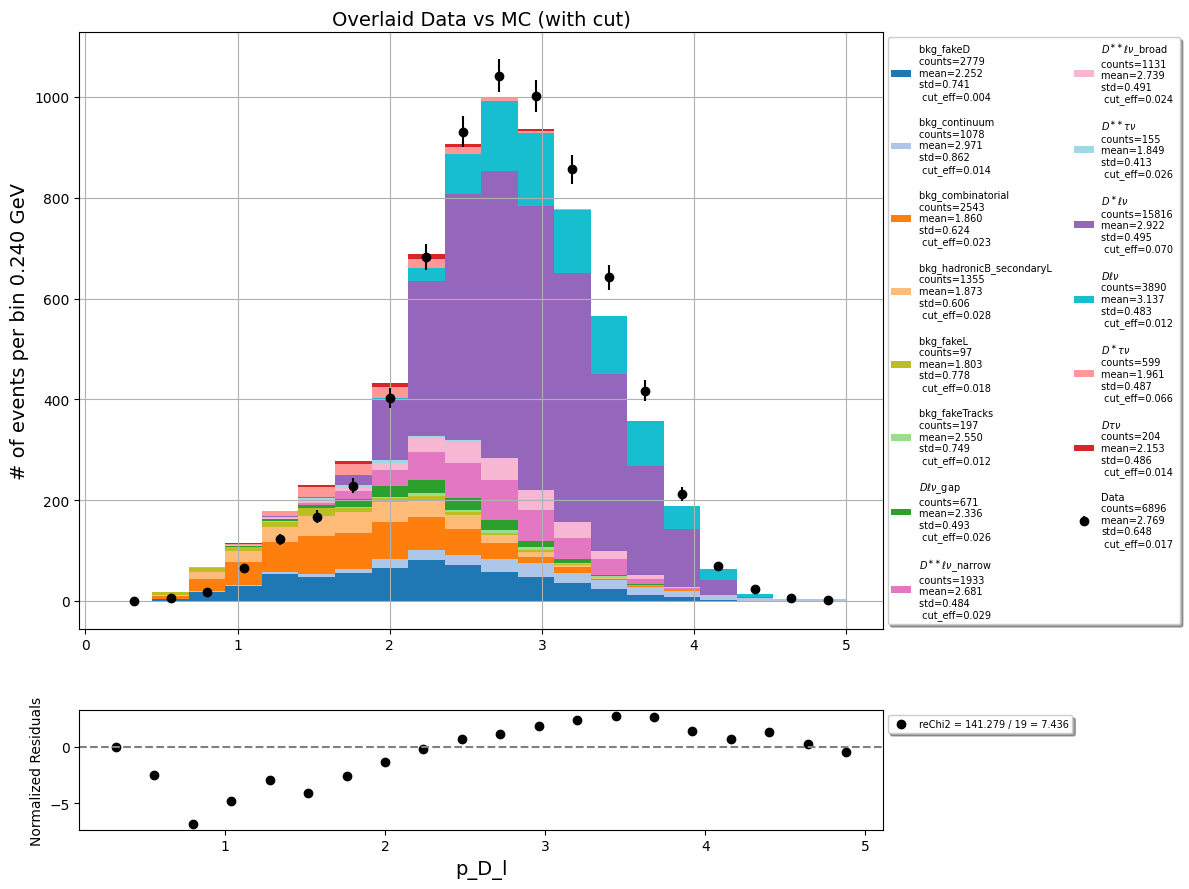

In [19]:
# exp<18
b1 = np.linspace(0.2,5,21)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.9, r'$D^{\ast\ast}\ell\nu$_narrow':0.25*0.7,r'$D^{\ast\ast}\ell\nu$_broad':0.25*0.7,
        # 'bkg_singleBbkg':0.25*0.5, 'bkg_combinatorial':0.25*0.5}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='p_D_l',bins=b1,cut=f'0.135<DstVeto_massDiff_0<0.145 and {lgb_tight} and 1.855<D_M<1.885 and experiment<18',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight')

cut= sig_prob>0.5 and fakeD_prob<0.06 and continuum_prob<0.4 and combinatorial_prob<0.6 and 0<B0_recMissM2<3 and 0.135<DstVeto_massDiff_0<0.145


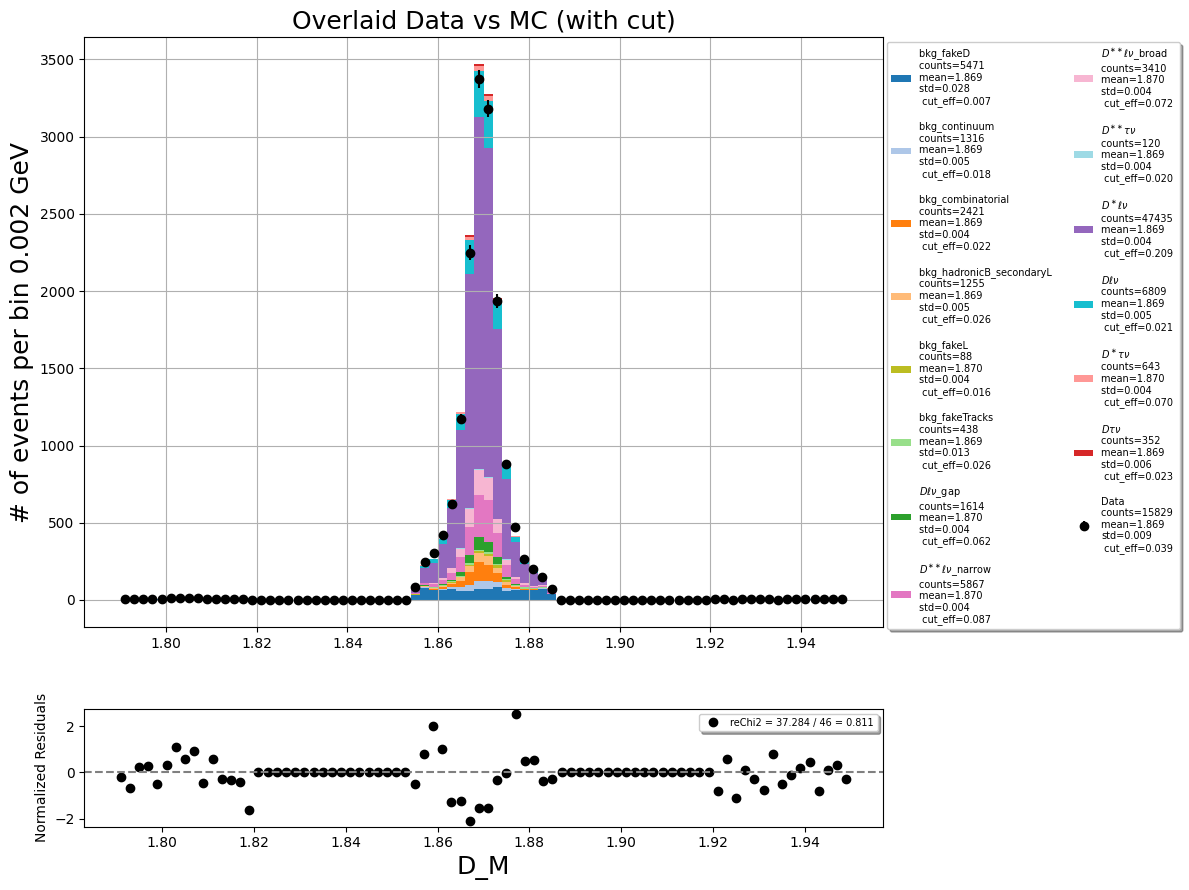

In [18]:
b1 = np.linspace(1.79,1.95,81)
weights={'all_mc':0.25,}# r'$D^\ast\ell\nu$':0.25*0.7, r'$D^{\ast\ast}\ell\nu$':0.25*0.7,r'$D\ell\nu$':0.25*1.05,}
data_hist_all, mc_hist_all = mpl.plot_data_mc_stacked(
    variable='D_M',bins=b1,cut=f'{lgb_tight} and 0<B0_recMissM2<3 and 0.135<DstVeto_massDiff_0<0.145',mask=[],
    figsize=(12,9),ratio=False,legend_nc=2,legend_fs=7,weights=weights,text_fs=18,
apply_eventByEvent_correction=True, eventByEvent_weight_col='total_weight')